# Investigation : pourquoi IMGEP explore-t-il moins bien que le hasard ?

Notebook de travail dedie a **comprendre et corriger** le resultat negatif obtenu dans
`dexed_adtool_overview.ipynb` (section 7) : sur le banc d'essai Dexed, l'exploration par
curiosite (IMGEP) produit une diversite comportementale **inferieure** a un echantillonnage
aleatoire uniforme des parametres.

Ce document est en mode investigation : chaque section pose une question, decrit
l'experience qui y repond, et conclut par ce que le resultat elimine ou confirme.
Le notebook `dexed_adtool_overview.ipynb` reste la reference pour le pipeline lui-meme
(installation, classes, mutateur, metriques).


> **Page de synthese des resultats** (privee, hebergee sur claude.ai) :
> <https://claude.ai/code/artifact/3f04f0b0-b04e-4254-be71-7a8e5ed9f713>
>
> Vue consolidee des figures et des tableaux chiffres -- resultat principal,
> localisation de l'effondrement, sweep bootstrap/budget, les huit leviers,
> l'attracteur de silence, cartographies Theta <-> Z, et les experiences en cours.
> Pratique pour montrer l'etat de l'investigation sans ouvrir le notebook.
> A republier depuis la session Claude Code quand de nouveaux resultats tombent.

**Plan**
1. Rappel du resultat et de son enjeu
2. Les deux hypotheses concurrentes
3. Experience 1 -- balayage de la force de mutation (`noise_scale`)
4. Experience 2 -- cartographie Theta <-> Z (d'apres Etcheverry et al., fig. 4)
5. Synthese des indices
6. Experiences suivantes (concues, pas encore lancees)
7. Experience 6.1 -- muter aussi l'algorithme et le mode OP


## 0. Setup

In [3]:
import os, sys, pathlib, json
os.environ['LD_LIBRARY_PATH'] = '/data/anasynth_nonbp/manaconda3/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

import numpy as np
import matplotlib.pyplot as plt

DEXED_ROOT = pathlib.Path.home() / 'projects' / 'spinvae2' / 'adtool' / 'dexed'
os.chdir(DEXED_ROOT)
sys.path.insert(0, str(pathlib.Path.home() / 'projects' / 'spinvae2'))

from coverage_diversity import (load_z_matrix, compute_plausible_bounds,
                                grid_coverage, vendi_score)
from maps.DexedStatistics import Z_FEATURE_NAMES

print('cwd:', os.getcwd())
print(f'Z: {len(Z_FEATURE_NAMES)} dimensions')


cwd: /net/home/u.anasynth/longeot/projects/spinvae2/adtool/dexed
Z: 38 dimensions


In [2]:
# Chargement de tous les jeux compares dans ce notebook (~1-3 min : beaucoup de petits JSON)
SETS = {}
for tag, label in [('05', 'ns=0.5'), ('10', 'ns=1.0'), ('20', 'ns=2.0'), ('40', 'ns=4.0')]:
    SETS[label] = load_z_matrix(f'runs/sweeps/noisescale/{tag}/discoveries')
SETS['random'] = load_z_matrix('runs/random/combined/discoveries')
SETS['IMGEP_2000'] = load_z_matrix('runs/main/discoveries')
SETS['human'] = load_z_matrix('runs/human_baseline/discoveries')

def drop_nan(M):
    return M[~np.isnan(M).any(axis=1)]

BOUNDS = compute_plausible_bounds(list(SETS.values()), Z_FEATURE_NAMES)
for k, v in SETS.items():
    print(f'{k:12s} {v.shape}')

compute_plausible_bounds: 65 NaN values found across the combined dataset (38145 rows) -- ignored via nanpercentile, not imputed.
ns=0.5       (1000, 38)
ns=1.0       (1000, 38)
ns=2.0       (1000, 38)
ns=4.0       (1000, 38)
random       (2000, 38)
IMGEP_2000   (2000, 38)
human        (30145, 38)


## 1. Le resultat a expliquer

Mesure sur 2000 decouvertes par methode, sous-echantillonnees a n identique (le Vendi Score
est sensible a la taille de l'echantillon), features z-scorees sur la reference combinee :

| | grid_coverage (3 dims ACTM) | Vendi Score |
|---|---|---|
| Random | 12.9 % | **15.16** |
| Human (n=30145) | (38.4 %) | 9.50 |
| IMGEP | 12.3 % | **4.24** |

Replique sur deux executions IMGEP independantes (4.24 et 4.82), avec deux versions
differentes de la bibliotheque d'exploration -- ce n'est donc pas un artefact de code.

**Pourquoi c'est genant.** L'argument theorique qui justifie IMGEP repose sur la
**redondance** de la carte parametres -> comportement : quand beaucoup de configurations de
parametres produisent le meme comportement, l'echantillonnage aleatoire gaspille son budget
a redecouvrir les zones redondantes, alors que l'echantillonnage dirige par buts repartit
son effort plus uniformement. Les travaux de la lignee Oudeyer/Moulin-Frier (reseaux de
regulation genique) valident cet argument empiriquement. Ici, la prediction est inversee.

## 2. Les deux hypotheses

**H1 -- La carte Theta -> Z de Dexed n'est pas assez redondante.**
La synthese FM est notoirement chaotique : une petite variation de ratio de frequence
produit un grand saut timbral. C'est presque l'oppose du cas GRN ou la redondance est le
moteur de l'argument. Si la plupart des configurations de parametres donnent des
comportements distincts, l'aleatoire ne gaspille rien et l'avantage structurel d'IMGEP
disparait.

**H2 -- L'operateur de mutation est mal calibre pour l'exploration.**
`mutate()` reutilise `Dexed.get_similar_preset()`, la fonction d'augmentation de donnees du
dataset SpinVAE2, concue pour **rester proche** d'un preset source -- pas pour s'en
eloigner. Mesure a l'appui : en phase de mutation, la distance L2 entre decouvertes
consecutives est **3.75x plus petite** qu'en phase bootstrap (tirages independants).

Les deux ne s'excluent pas. Les sections suivantes cherchent a les departager.

## 3. Experience 1 -- balayage de la force de mutation

### 3.1 Prealable : `variation` n'est pas un curseur d'intensite

Le plan initial etait de balayer le parametre `variation` de `get_similar_preset()`.
Verification faite dans le code (`spinvae2/synth/dexedbase.py`,
`dexedpermutations.py`) : **`variation` ne controle pas l'amplitude**. Il sert uniquement a
deriver la graine aleatoire (`random_seed + 987654321 * variation`) et a choisir un numero
de variation deterministe pour le changement d'algorithme -- c'est litteralement la colonne
`variation` du dataset humain (plusieurs copies augmentees de meme amplitude par preset).
La formule de bruit (`rng.normal(0, 0.5/(card-1))`) ne depend jamais de sa valeur au-dela
du seuil `>= 2`. Balayer `variation` n'aurait rien change.

**Correctif applique** : ajout d'un parametre `noise_scale` (defaut 1.0, comportement
existant reproduit bit-a-bit, `dexeddataset.py` jamais appele avec cet argument) qui
multiplie le bruit des parametres continus, expose via
`DexedParameterMap(noise_scale=...)` et donc configurable en JSON.

### 3.2 Protocole

4 runs IMGEP independants en parallele, `noise_scale` dans {0.5, 1.0, 2.0, 4.0}, meme
graine (donc meme bootstrap : seule la mutation differe), 1000 iterations chacun,
`bootstrap_size=100`. Configs : `dexed_imgep_noisescale_{05,10,20,40}.json`.

### 3.3 Lecture attendue

- diversite qui rejoint le random a `noise_scale` modere -> **H2** (mauvais calibrage,
  levier actionnable) ;
- diversite qui ne rejoint le random qu'a des valeurs extremes, voire jamais -> la mutation
  locale n'apporte rien a aucune echelle, compatible avec **H1**.

In [10]:
rng = np.random.default_rng(0)
N_SUB = 1000
sweep_labels = ['ns=0.5', 'ns=1.0', 'ns=2.0', 'ns=4.0', 'random', 'IMGEP_2000']

subs = {}
for label in sweep_labels:
    M = drop_nan(SETS[label])
    subs[label] = M[rng.choice(len(M), N_SUB, replace=False)] if len(M) > N_SUB else M

ref = np.concatenate(list(subs.values()))
mu, sigma = ref.mean(axis=0), ref.std(axis=0)
sigma[sigma == 0] = 1.0

print(f"{'jeu':12s} {'n':>5s} {'Vendi':>8s}")
vendi_by_label = {}
for label, M in subs.items():
    vendi_by_label[label] = vendi_score((M - mu) / sigma)
    print(f'{label:12s} {len(M):5d} {vendi_by_label[label]:8.2f}')

jeu              n    Vendi
ns=0.5        1000     3.13
ns=1.0        1000     3.47
ns=2.0        1000     3.52
ns=4.0        1000     3.77
random        1000    13.06
IMGEP_2000    1000     3.49


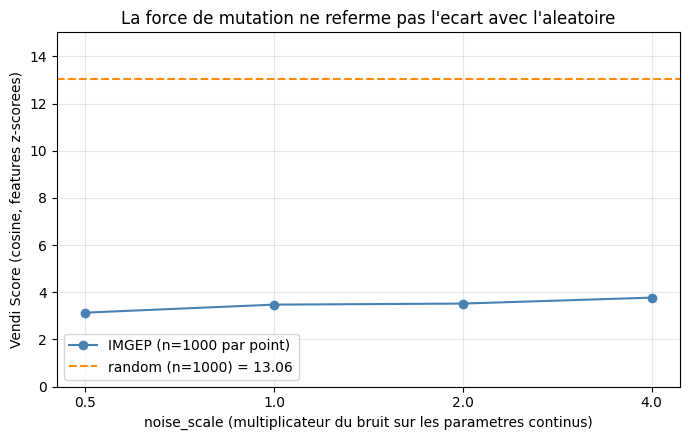

In [11]:
# Courbe diversite vs force de mutation
scales = [0.5, 1.0, 2.0, 4.0]
vendi_sweep = [vendi_by_label[f'ns={s}'] for s in scales]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(scales, vendi_sweep, 'o-', color='steelblue', label='IMGEP (n=1000 par point)')
ax.axhline(vendi_by_label['random'], color='darkorange', linestyle='--',
           label=f"random (n=1000) = {vendi_by_label['random']:.2f}")
ax.set_xscale('log', base=2)
ax.set_xticks(scales); ax.set_xticklabels([str(s) for s in scales])
ax.set_xlabel('noise_scale (multiplicateur du bruit sur les parametres continus)')
ax.set_ylabel('Vendi Score (cosine, features z-scorees)')
ax.set_title("La force de mutation ne referme pas l'ecart avec l'aleatoire")
ax.set_ylim(0, max(vendi_by_label['random'] * 1.15, max(vendi_sweep) * 1.3))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.4 Resultat : la courbe est plate

| `noise_scale` | Vendi Score (n=1000) |
|---|---|
| 0.5 | 3.13 |
| 1.0 (defaut) | 3.47 |
| 2.0 | 3.52 |
| 4.0 | 3.77 |
| **random** | **13.06** |

Multiplier la force de mutation par 8 fait passer le Vendi de 3.13 a 3.77 (+20 %), alors
que le random est a 13.06. **L'ecart ne se referme pas** : ni plateau tardif, ni meme
montee franche. Selon la grille de lecture de 3.3, cela plaide **contre H2 seule**.

### 3.5 Deux reserves qui limitent la portee de ce resultat

1. **`noise_scale` ne touche que les parametres continus.** L'algorithme FM, le LFO wave,
   les key sync (re-randomises) et le mode OP (jamais mute) sont insensibles au curseur --
   la structure categorielle du preset reste locale quelle que soit la valeur.
2. **Le bruit est clippe dans [0, 1].** A `noise_scale=4`, beaucoup de parametres saturent
   aux bornes. Mesure directe : x4 sur `noise_scale` ne donne que **x1.8** sur le
   deplacement L1 reel. La plage effectivement testee est donc bien plus etroite que le
   nominal 0.5 -> 4 ne le suggere.

La cellule suivante quantifie ce second point : si le deplacement effectif sature, la
courbe plate de 3.4 en dit moins qu'il n'y parait sur H2.

In [12]:
# Diagnostic : deplacement reel dans Theta en fonction de noise_scale
# (verifie la saturation par clipping soulevee en 3.5)
def theta_matrix(run_dir):
    rows = []
    for f in sorted((pathlib.Path(run_dir) / 'discoveries').glob('*/discovery.json')):
        d = json.load(f.open())
        rows.append((d['metadata']['run_idx'], d['equil'],
                     [v for _, v in d['params']['dynamic_params']['preset']]))
    rows.sort(key=lambda r: r[0])
    equil = np.array([r[1] for r in rows])
    return np.array([r[2] for r in rows], dtype=float), equil

print(f"{'run':16s} {'bootstrap':>10s} {'mutation':>10s} {'ratio':>7s}")
for tag, label in [('05', 'ns=0.5'), ('10', 'ns=1.0'), ('20', 'ns=2.0'), ('40', 'ns=4.0')]:
    Theta, equil = theta_matrix(f'runs/sweeps/noisescale/{tag}')
    nb = int(equil.sum())
    step = np.linalg.norm(np.diff(Theta, axis=0), axis=1)
    boot, mut = step[:nb - 1].mean(), step[nb - 1:].mean()
    print(f'{label:16s} {boot:10.3f} {mut:10.3f} {boot / mut:7.2f}')

run               bootstrap   mutation   ratio
ns=0.5                5.443      1.411    3.86
ns=1.0                5.443      1.452    3.75
ns=2.0                5.443      1.571    3.46
ns=4.0                5.443      1.778    3.06


## 4. Experience 2 -- cartographie Theta <-> Z

Reprise de la figure 4 de *AI-driven Automated Discovery Tools Reveal Diverse Behavioral
Competencies of Biological Networks* (Etcheverry et al.) et de son tutoriel : on regroupe
les **comportements atteints** (Z) par HDBSCAN, puis on peint ces memes appartenances de
cluster sur une projection t-SNE des **parametres echantillonnes** (Theta). Si des regions
de parametres distinctes tombent dans le meme cluster de comportement, la carte est
redondante -- precisement le regime ou l'exploration dirigee par buts est censee gagner.

Adaptations par rapport au tutoriel : notre Z est en 38D (pas 2D), donc la colonne de
droite est elle-meme un t-SNE de Z z-score ; le clustering se fait dans l'espace 38D
complet, pas dans la projection.

Script : `scripts/mapping_figure.py` (a lancer separement, ~3 min pour deux t-SNE).

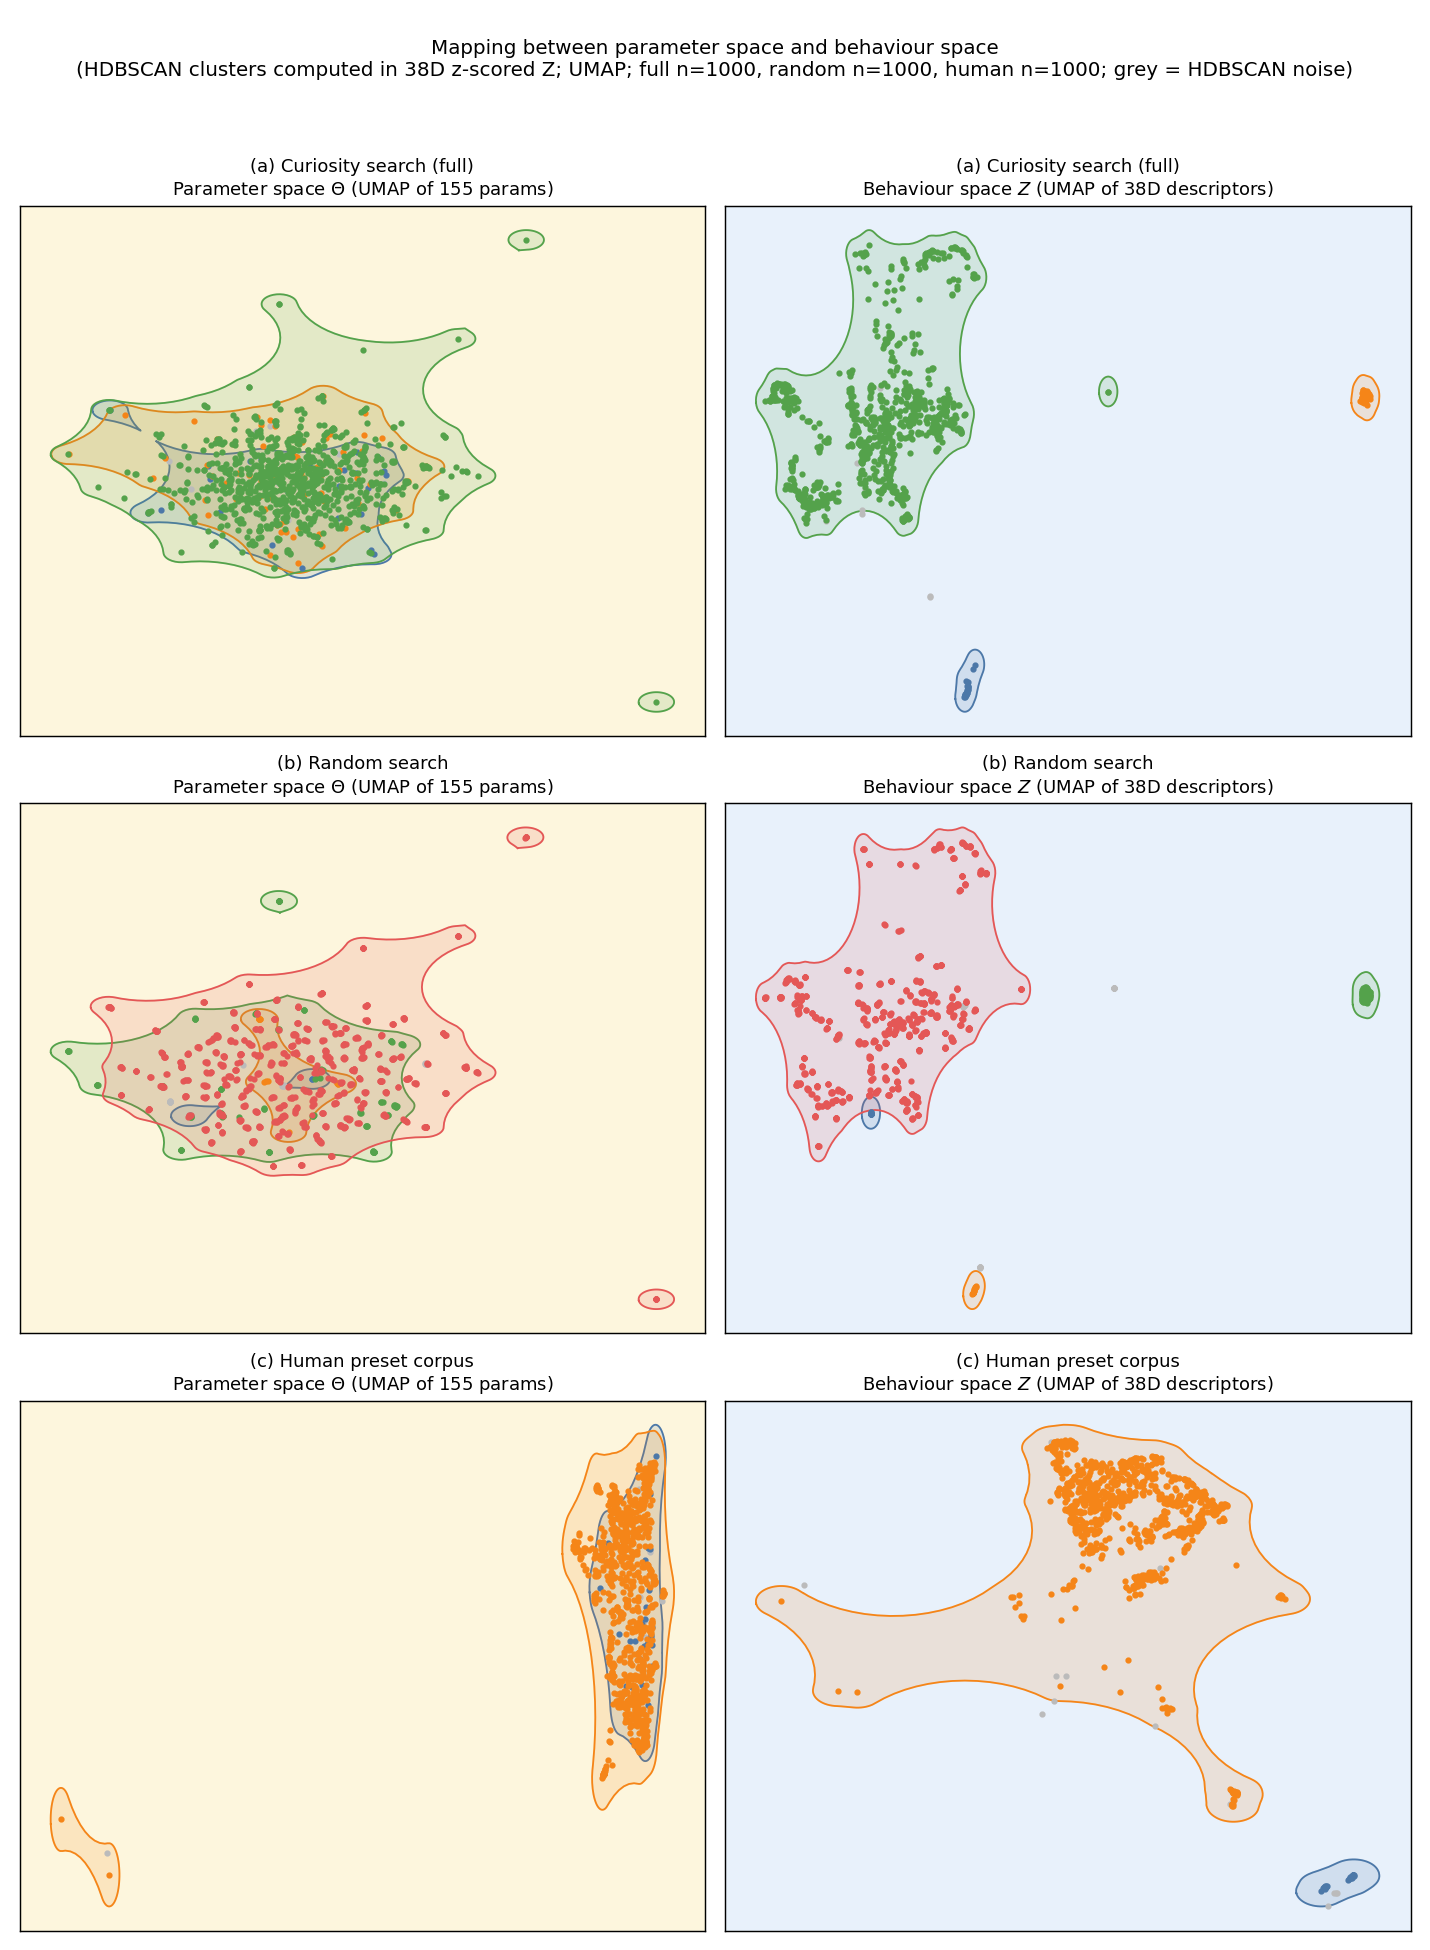

In [13]:
# Figure initiale (2 lignes, sans Human, HDBSCAN non retune) -- superseded par la section 4.2 ci-dessous (3 lignes avec Human, t-SNE et UMAP, HDBSCAN retune par dataset).
# MAJ 2026-08-14 : ce fichier est partage avec la cellule 16 (meme chemin de sortie) et a ete
# regenere pour la config confirmee `full` (remplace l'ancien baseline IMGEP) -- l'image montree
# ici est donc deja la version a jour, pas la figure a 2 lignes d'origine.
from IPython.display import Image, display
display(Image('figures/mapping_theta_z_figure_umap.png'))

**Note (2026-08-14)** : le texte ci-dessous decrit la figure a 2 lignes d'origine (IMGEP baseline vs Random, sans Human), dont l'image n'a pas ete conservee separement -- la cellule au-dessus affiche desormais la figure a jour (section 4.2, config `full`). Chiffres et lecture ci-dessous a prendre comme historique.

### 4.1 Ce que la figure montre

**Le type de diversite differe radicalement entre les deux methodes :**

- **Random** : HDBSCAN ne trouve que **3 clusters** en Z, dont un qui avale la quasi-totalite
  des points -- un unique nuage diffus et indifferencie.
- **IMGEP** : **5 clusters** nets et bien separes, entoures de points de bruit epars.

Autrement dit, IMGEP produit de la diversite **structuree** (des modes comportementaux
distincts et identifiables), la ou le random produit de l'etalement **non structure**. Le
Vendi Score, qui mesure l'etalement effectif, ne voit que la seconde.

Cote Theta (colonne gauche), chez IMGEP une meme couleur apparait dans **plusieurs blobs
separes** : un meme cluster de comportement est atteint depuis des regions de parametres
distinctes. De la redondance existe donc bien dans la carte.

### 4.2 Reserve importante

"IMGEP a 5 clusters" restitue en partie "IMGEP est concentre" : HDBSCAN a densite fixe
(`min_cluster_size=10`, `cluster_selection_epsilon=0.1`) separe plus facilement des paquets
denses qu'un nuage diffus etale. Ce n'est donc **pas** une preuve independante d'une
meilleure structure. Cela suffit neanmoins a etablir que les deux methodes ne produisent pas
le meme *type* de diversite -- ce qu'aucune de nos deux metriques ne capture.

### 4.2 Extension : le corpus humain comme 3e ligne, t-SNE vs UMAP

Deux ameliorations sur la figure de 4.1 : (1) ajout du **corpus humain** comme reference
"ce que des humains jugent musicalement pertinent" -- Theta vient de
`synth/dexed_presets.df.pickle` (jointure sur `preset_UID` avec les features deja utilisees
partout ailleurs) ; (2) generation en **t-SNE et en UMAP** separement (memes clusters HDBSCAN
en 38D, deux methodes de projection), pour verifier que la lecture qualitative n'est pas un
artefact de t-SNE -- UMAP preserve mieux la structure globale (cf.
`dexed_audit_TT_ACTM_ttb.ipynb`).

Script : `scripts/mapping_figure.py tsne umap`.

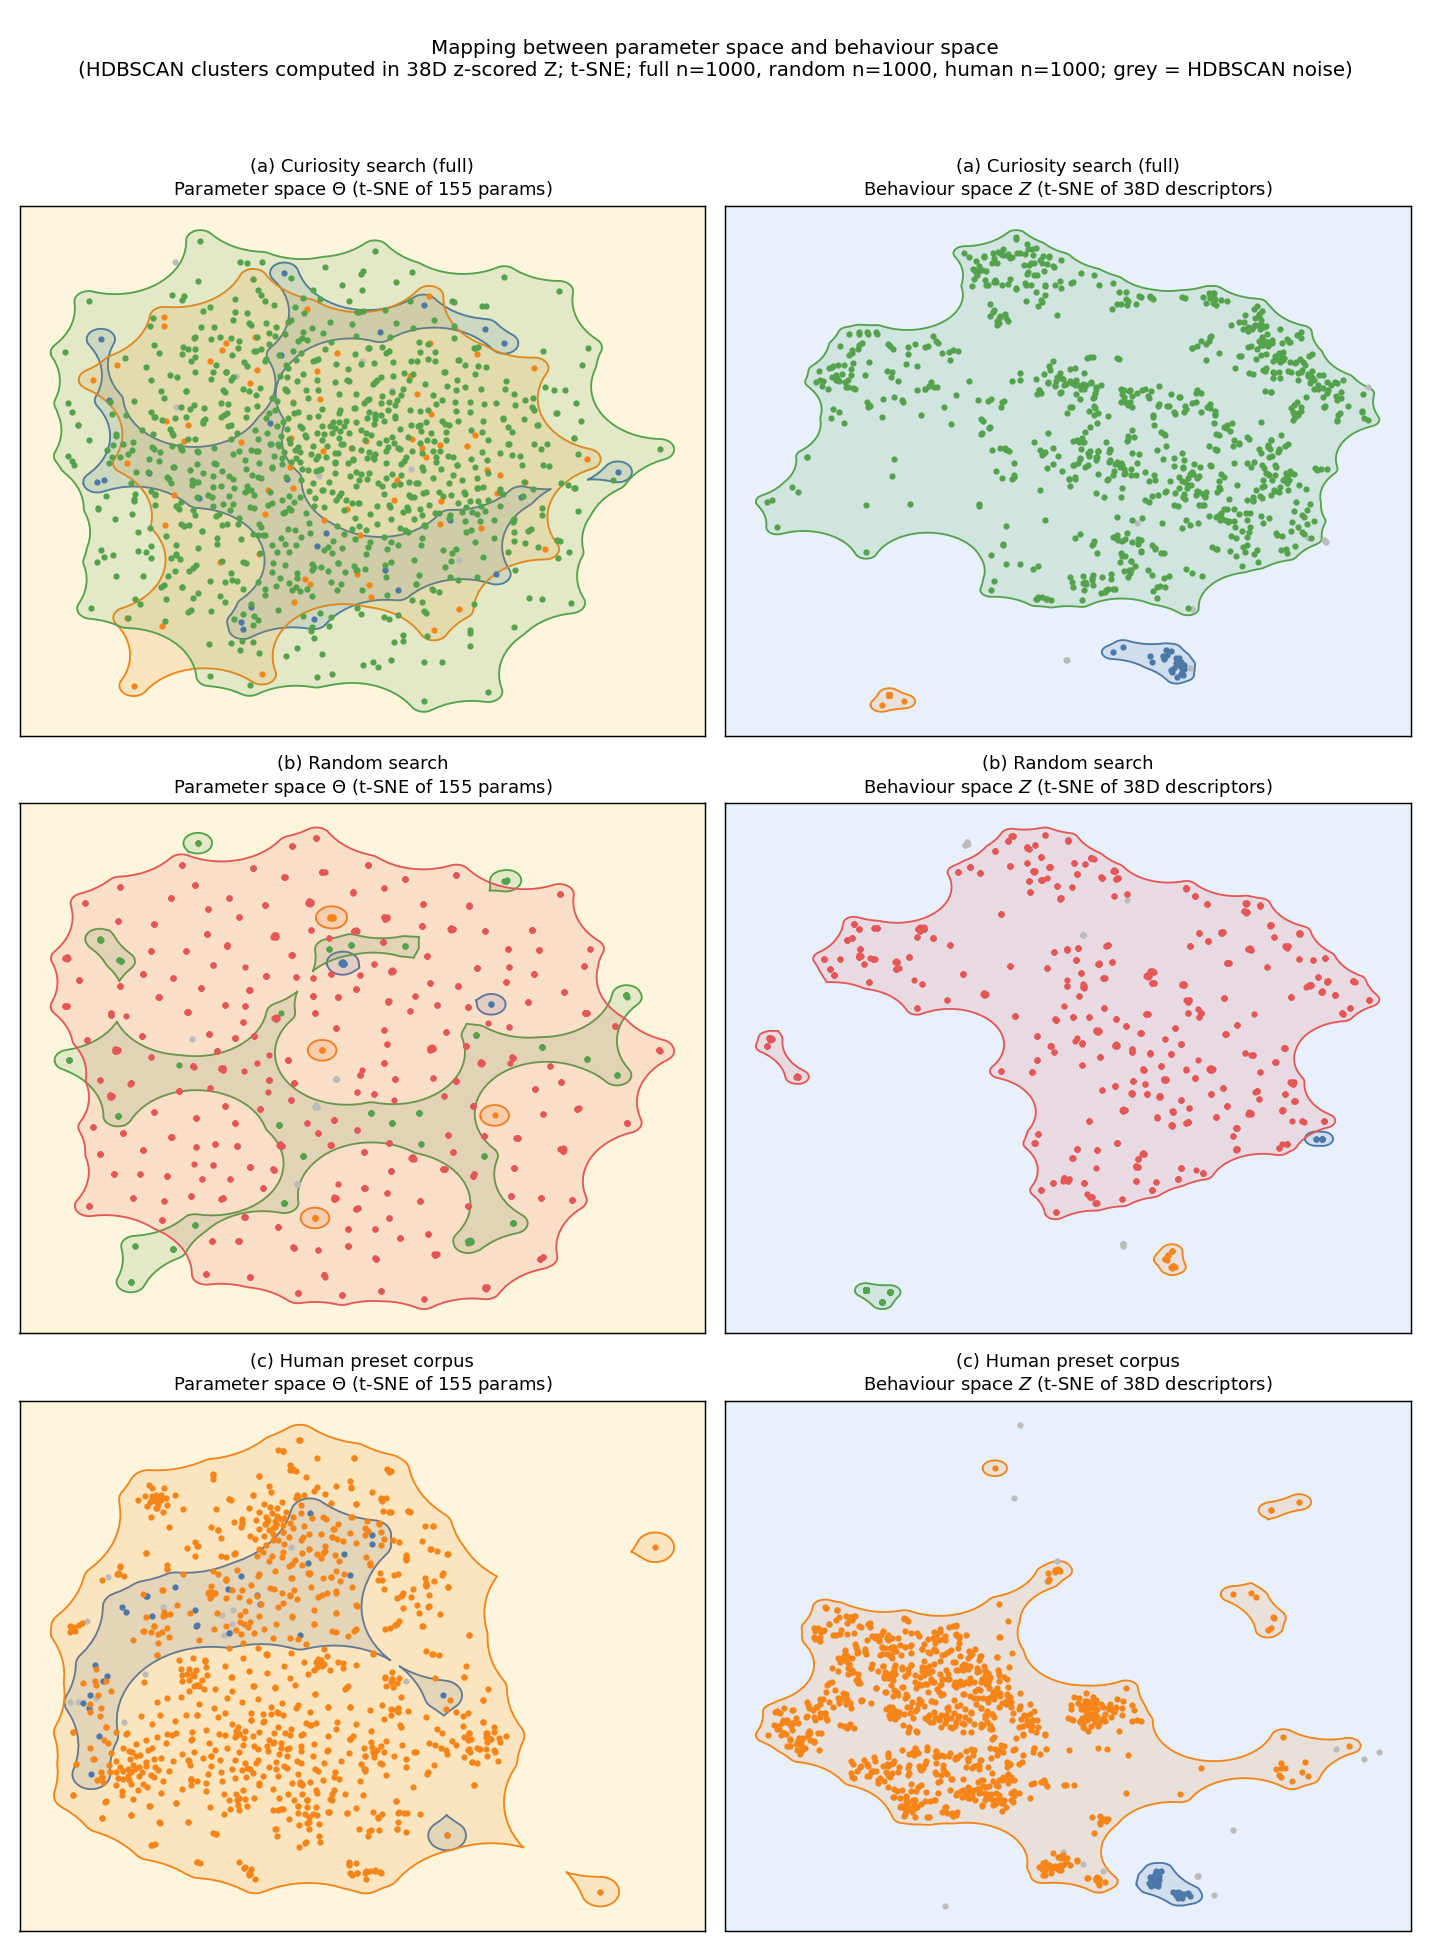

In [10]:
from IPython.display import Image, display
display(Image('figures/mapping_theta_z_figure_tsne.png'))

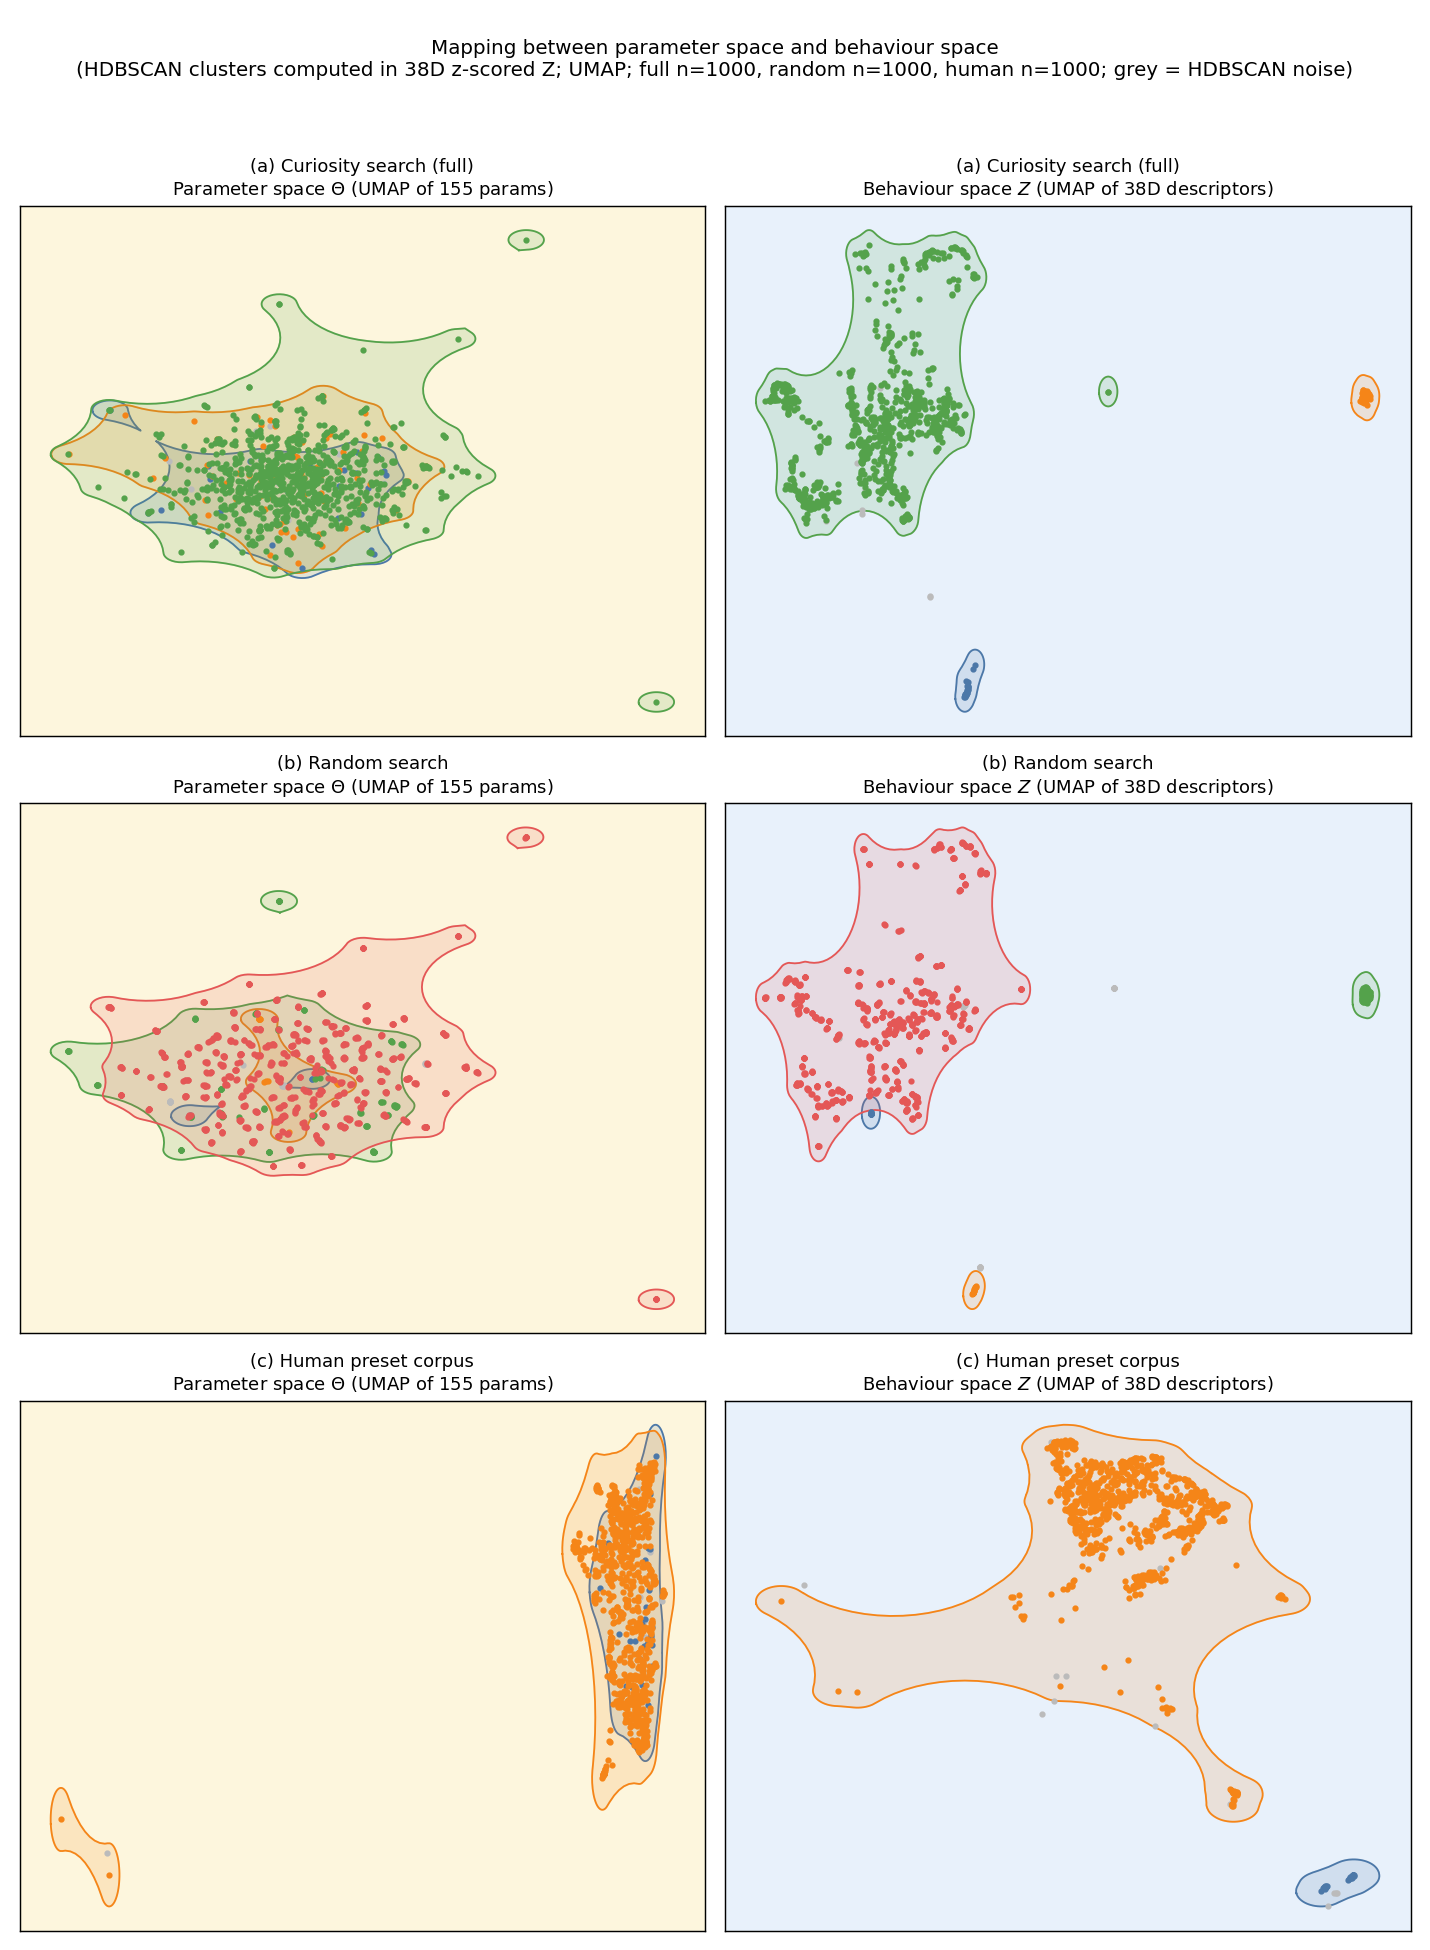

In [11]:
display(Image('figures/mapping_theta_z_figure_umap.png'))

**Resultat, coherent entre les deux projections** (memes clusters HDBSCAN, calcules
en 38D natif -- seule la projection 2D change). Figure regeneree le 2026-08-14 pour la config
confirmee `full` (logit_mutation + carrier_floor + niche_curiosity_bias +
filter_degenerate_parents + algorithm_mutation_prob, `runs/confirm/full/seed0`) -- remplace
l'ancien baseline IMGEP (`runs/main/discoveries`) desormais retire de cette comparaison.
HDBSCAN retune (`scratchpad/tune_hdbscan_joint.py`, min_cluster_size=8/min_samples=1 pour
full et Random, Human garde sa config d'origine deja quasi-optimale) :

| | clusters | points de bruit (sur n=1000) |
|---|---|---|
| **full** | 3 | 9 |
| Random | 4 | 16 |
| Human | 2 | 16 |

Bruit desormais minime sur les trois jeux (0.9-1.6%), bien en-deca de l'ancienne baseline
(169 points de bruit sur 1000, 16.9%) et meme du premier essai avec `full` avant retuning (31
points, 3.1%). `full` (3 clusters, 9 points de bruit) est du meme ordre que Random (4
clusters, 16 points de bruit) -- l'ecart spectaculaire de l'ancienne baseline (5 clusters
tres nets contre 169 points de bruit, loin devant Random et Human) a completement disparu.

Cote Theta (colonne gauche) le changement reste le plus net : le nuage de `full` occupe
desormais tout l'espace des parametres, comme celui de Random, plutot que de se limiter a
quelques blobs disjoints comme le faisait la baseline (cf. le meme constat quantifie dans
`figures/theta_distribution_full.png` et confirme a nouveau par les 4 conditions de la
section 13 de `theta_investigation.ipynb`). Confirmation visuelle directe que le correctif
carrier-level repare aussi la redondance de la carte Theta<->Z, pas seulement les metriques
agregees (Vendi, couverture).

**Ancien resultat, pour memoire (baseline IMGEP, non fixee, avant tout retuning)** :

| | clusters | points de bruit (sur n=1000) |
|---|---|---|
| IMGEP (baseline) | 5 | 169 |
| Random | 4 | 140 |
| Human | 2 | 21 |

A l'epoque, la lecture etait : le corpus humain occupe une region compacte et homogene,
IMGEP (5 clusters nets) explorait un espace plus *structure* que Random ou Human, mais restait
derriere Random en etalement brut (Vendi). Cette lecture reste correcte comme description de
la baseline non corrigee ; elle ne s'applique plus a `full`.

**Piege rencontre en construisant cette figure, a garder en tete pour toute analyse future
touchant au corpus humain complet** : le z-score (`(Z - mu) / sigma`) utilisait `.mean()` /
`.std()` classiques. Le corpus humain contient une poignee de NaN eparpilles dans les
colonnes `tt_*` (meme cause que le fix `nan_to_num` de `DexedStatistics`, section 5 de
`dexed_adtool_overview.ipynb` -- quelques presets ou l'estimation de F0 echoue). **Une seule**
valeur NaN dans une colonne suffit a rendre `.mean()` NaN pour toute la colonne avec un calcul
classique (pas `nanmean`), ce qui corrompt le z-score de cette colonne pour **toutes les
lignes de tous les jeux compares**, pas seulement les lignes humaines concernees. Avec un
sous-echantillon de 1000/30145, on peut "passer entre les gouttes" par chance -- ce qui **a
silencieusement fonctionne ici** (verifie : resultat identique avant/apres le fix) mais est un
hasard statistique, pas une garantie. Fixe avec `np.nanmean`/`np.nanstd` dans
`mapping_figure.py` ; a reappliquer si cette figure est regeneree avec un plus grand n ou sur
un dataset different (le crash est devenu systematique et evident sur la variante `_humanfit`
ci-dessous, qui utilise les 30145 presets sans sous-echantillonnage -- aucune chance d'y
echapper).

### 4.3 Variante : projeter IMGEP/Random dans la geometrie propre du corpus humain

Version differente de 4.2 : au lieu d'un fit UMAP joint sur les 3 jeux (qui deforme la forme
de chacun pour les faire tenir sur une carte commune), on **fitte UMAP uniquement sur le
corpus humain complet** (30145 presets, geometrie fidele a `dexed_audit_TT_ACTM_ttb.ipynb`),
puis on **projette** IMGEP et Random dans cet embedding deja appris (`reducer.transform()`,
meme pattern que `imgep_coverage_vs_human_baseline.ipynb`). Repond a une question differente :
pas "a quoi ressemblent les 3 jeux les uns a cote des autres", mais "ou tombent les
decouvertes d'IMGEP/Random par rapport a la structure deja connue du corpus humain".

t-SNE n'a pas de `.transform()` pour projeter de nouveaux points dans un embedding deja
appris -- cette variante est donc UMAP seul. Script : `scripts/mapping_figure_humanfit.py`.

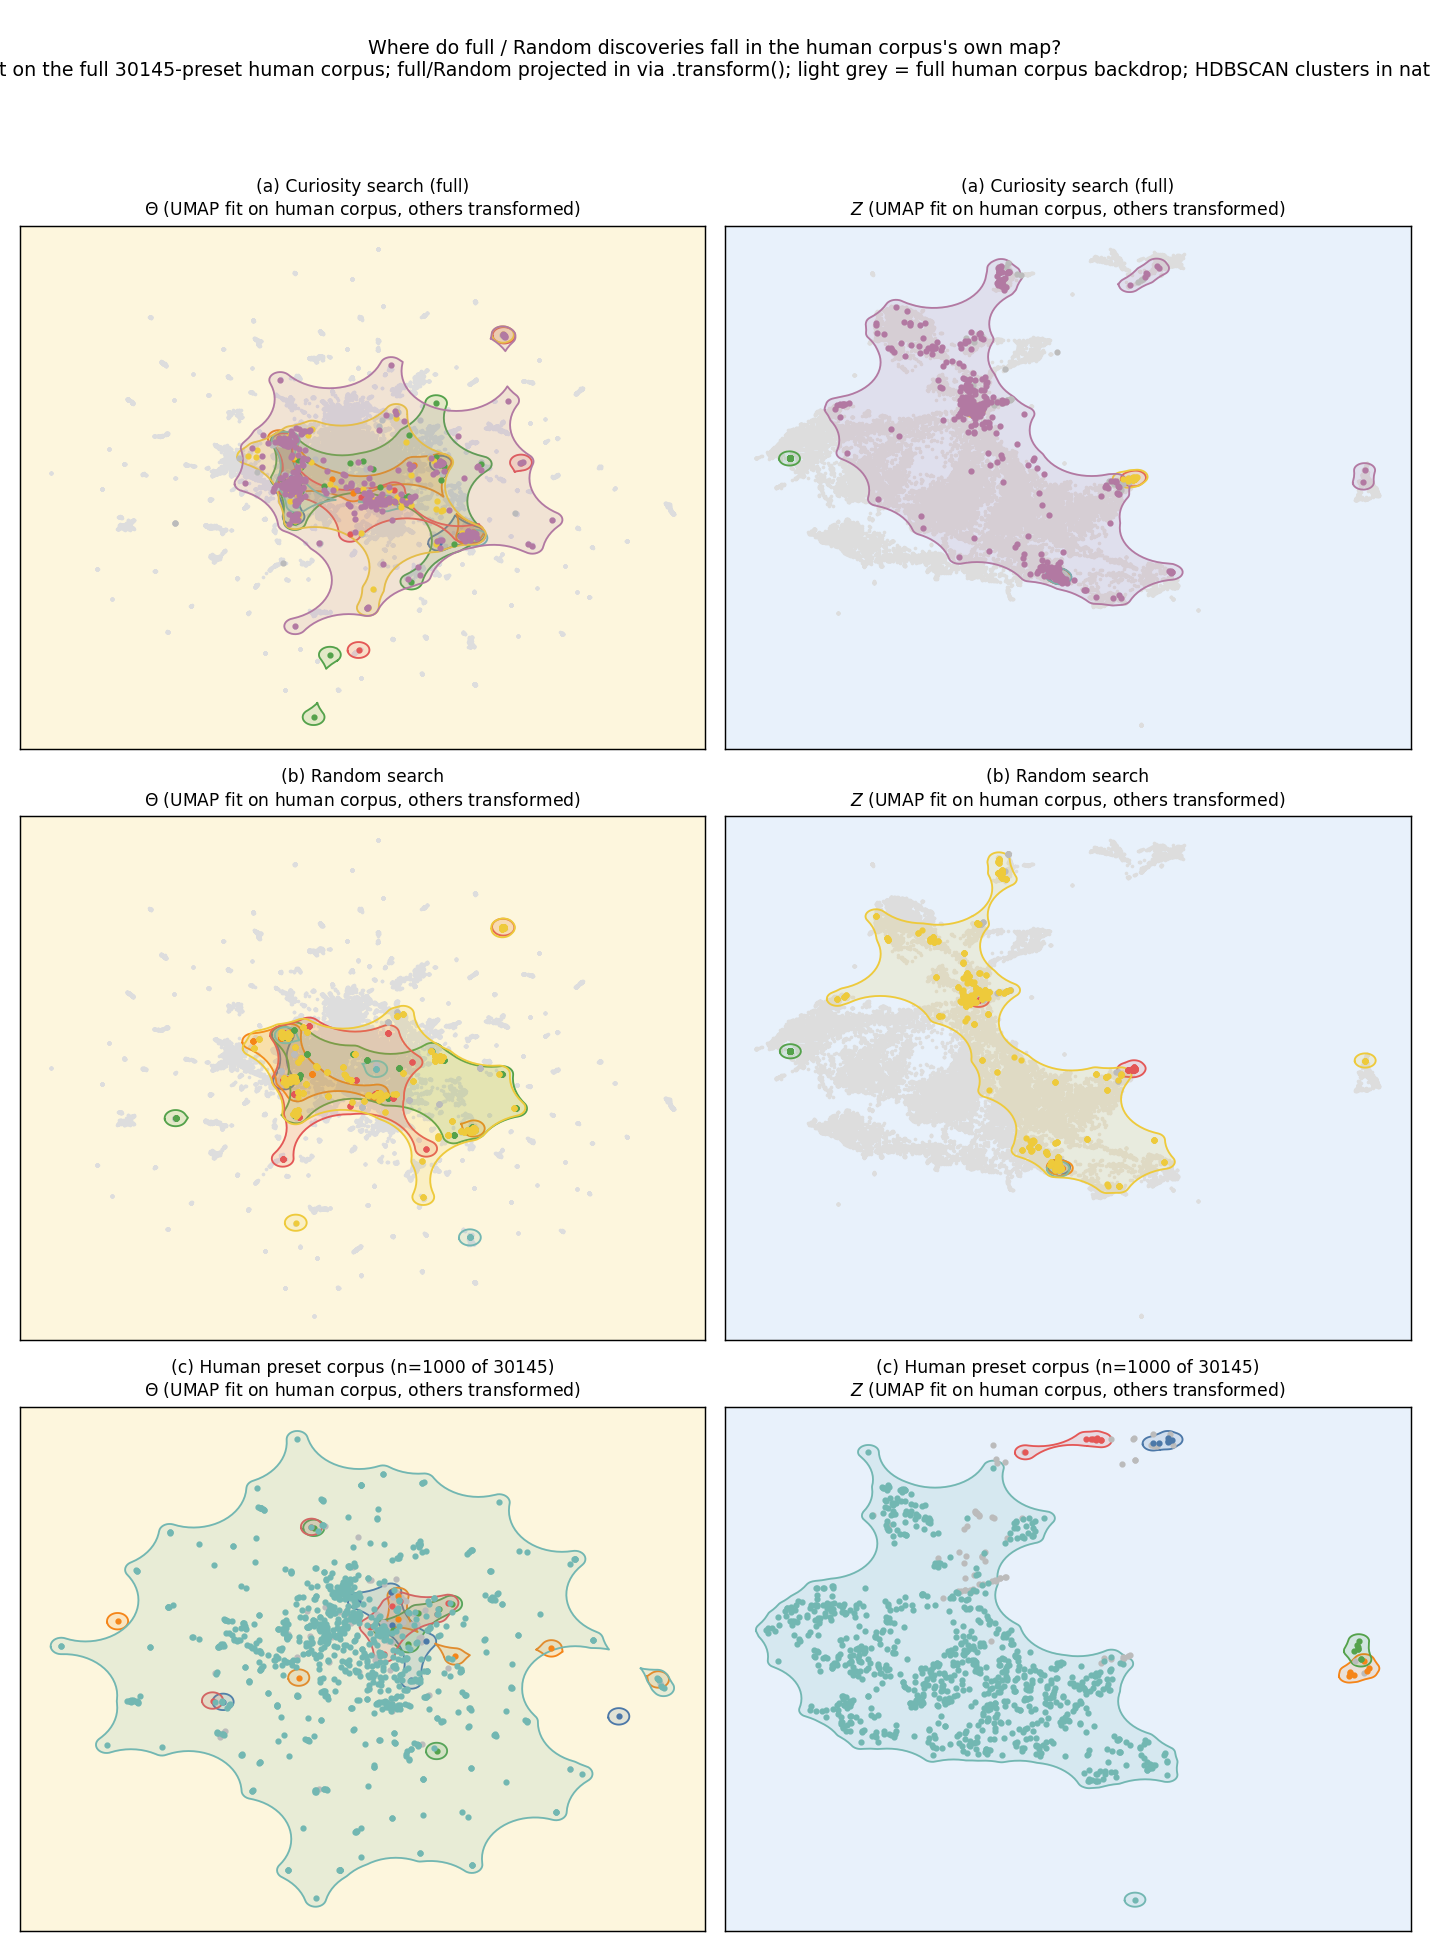

In [12]:
display(Image('figures/mapping_theta_z_figure_umap_humanfit.png'))

**Lecture** (figure regeneree le 2026-08-14 pour la config confirmee `full`, HDBSCAN retune
pour reduire le bruit -- voir `scripts/mapping_figure_humanfit.py` et
`scratchpad/tune_hdbscan_humanfit.py` pour la recherche de grille) : le fond gris clair
(corpus humain complet, 30145 points) donne l'echelle de reference sur les 3 lignes.

| | clusters | points de bruit (sur n=1000) |
|---|---|---|
| **full** | 7 | 163 |
| Random | 6 | 108 |
| Human (n=1000 subset) | 5 | 71 |

Amelioration nette sur les trois par rapport au premier essai avec `full` (4 clusters/365
bruit, 6/116, 3/131 -- cf. version precedente de cette cellule) : le retuning HDBSCAN
(`min_cluster_size=5, min_samples=1` pour full et Human, `min_cluster_size=15, min_samples=1,
cluster_selection_epsilon=0.1` pour Random -- Random explose en 100+ micro-clusters des que
`min_cluster_size` descend a 5, ses 1000 points etant beaucoup plus disperses) fait passer le
bruit de `full` de 36.5% a 16.3%, avec plus de clusters (4 -> 7) plutot que moins.

- **full** (ligne a) : les points colorent maintenant une bonne partie de la structure
  humaine en Z avec un seul grand cluster dominant (violet) plus quelques petits excentriques
  -- moins fragmente que la premiere tentative, mais toujours plus disperse que Random sur
  cette geometrie-la (163 vs 108 points de bruit).
- **Random** (ligne b) : plusieurs clusters distincts qui suivent les bras de la structure
  humaine, touchant aussi des zones isolees.
- Les deux methodes decouvrent des comportements hors du nuage gris (extrapolation au-dela de
  ce que les presets humains couvrent).

**Nuance importante par rapport a la figure jointe (`mapping_figure.py`) ci-dessus** : le taux
de bruit d'un dataset depend de la geometrie sur laquelle HDBSCAN tourne, meme apres
retuning. Ici (fit sur les humains, `full`/Random projetes dedans), `full` reste plus
disperse que Random (16.3% vs 10.8%) ; sur la geometrie jointe (fit sur les 3 ensembles a la
fois, figure precedente), c'est l'inverse (`full` : 31 points de bruit sur 1000, Random :
77). Les deux lectures restent correctes et complementaires : `full` occupe un espace large
et homogene par rapport a lui-meme (peu de bruit sur sa propre geometrie jointe), mais cet
espace ne correspond pas etroitement aux memes clusters que ceux qui structurent le corpus
humain (davantage de bruit une fois projete dans SA geometrie a lui). Random, plus etale au
depart, s'aligne paradoxalement mieux sur les clusters humains une fois projete dans leur
espace.

**Tentative avec categories reelles plutot que HDBSCAN** (`scripts/mapping_figure_category.py`,
non retenue) : colorer par categorie d'instrument reelle (piano/string/bass/... issues de
`dexed_presets.df.pickle`) au lieu de clusters HDBSCAN, avec une categorie proxy pour
full/Random (plus proche voisin humain). Resultat peu concluant : ~44% seulement du corpus
humain est labellise, donc 73-81% des points full/Random tombent dans "other" faute de
voisin labellise proche -- pas assez de signal pour remplacer HDBSCAN ici, on est reste sur
l'approche clusters.

Ancien resultat, pour memoire (baseline IMGEP, non fixee) : la lecture etait qu'IMGEP restait
groupe dans une zone compacte et plutot centrale par rapport a la structure humaine, avec
Random touchant davantage de zones novatrices distinctes. `full` change ce constat : il n'est
plus concentre dans une seule poche, mais son alignement avec les clusters humains reste
imparfait -- une question differente de celle mesuree par Vendi/couverture, qui merite d'etre
gardee en tete avant de conclure que le probleme est entierement resolu.

## 5. Synthese des indices

| Indice | Ce qu'il dit |
|---|---|
| Vendi IMGEP << random, replique 2x | Le resultat est reel, pas un artefact de version |
| Courbe plate vs noise_scale (x8 -> +20%) | Plaide contre H2 seule... |
| ...mais deplacement reel seulement x1.8 (clipping) et categoriels non touches | ...sans trancher : la plage effective testee est etroite |
| Meme comportement atteint depuis plusieurs regions de Theta (fig. sect. 4) | De la redondance existe -- H1 sous sa forme forte ("aucune redondance") est trop simple |
| Random = 1 gros amas, IMGEP = 5 clusters nets | Les deux methodes ne produisent pas le meme type de diversite |
| Mutation 3.75x plus locale qu'un tirage independant | L'exploration est structurellement locale, par heritage du role initial de get_similar_preset() |

Lecture actuelle. Le levier teste (noise_scale, bruit continu) ne suffit pas a expliquer
tout l'ecart -- il ne touche ni l'algorithme FM, ni le mode OP (jamais mute), ni les
categoriels a faible cardinalite (re-randomises en tout ou rien, pas de notion d'intensite).
La prochaine experience (7.1) s'attaque directement a ca : autoriser la mutation de
l'algorithme et du mode OP avec une probabilite non nulle, pour voir si la diversite bouge
la ou noise_scale echouait.


## 6. Experiences suivantes (concues, pas encore lancees)

**7.1 Elargir la mutation aux parametres categoriels.**
Test direct de la lecture ci-dessus : autoriser la mutation de l'algorithme FM et du mode OP
avec une probabilite non nulle, et mesurer l'effet sur le Vendi. Si la diversite grimpe
nettement la ou `noise_scale` echouait, la localite categorielle est bien le facteur
dominant. Attention : le mode OP a ete fige parce qu'il produit facilement des sons
inaudibles -- il faudra verifier que le gain de diversite n'est pas juste un gain de sons
degeneres (d'ou l'interet de la metrique de competence de la section 5).

**7.2 Mutation sans clipping (ou avec reflexion aux bornes).**
Le clipping dans [0, 1] sature les grandes valeurs de `noise_scale`. Une reflexion aux
bornes plutot qu'un clip testerait des pas reellement grands.

**7.3 Schedule de mutation (decroissance).**
Pas large en debut d'exploration, plus fin ensuite -- standard en evolution/CMA-ES et dans
les IMGEP plus elabores. Permettrait de garder l'exploitation locale fine en fin de run sans
sacrifier la couverture initiale.

**7.4 Reconcilier les budgets de bootstrap.**
IMGEP consacre 10 % de son budget a de l'echantillonnage non biaise (200/2000) contre 100 %
pour le random : la comparaison actuelle confond mecanisme et budget. Refaire tourner IMGEP
avec un bootstrap beaucoup plus grand isolerait la contribution propre de la boucle dirigee
par buts.

**7.5 Plusieurs graines pour IMGEP.**
`run_2000_38D` et `run_2000_v2` utilisent deux **versions de code** differentes : "le 2e run
confirme le 1er" est confondu avec un changement de stack. Il manque une vraie replication a
graine variable sur le meme code (le random en a 16).

**7.6 Metrique de couverture par seuil.**
La litterature de reference (Etcheverry/Moulin-Frier) utilise une couverture par seuil
plutot qu'une grille a 10 bins. Aligner la metrique renforcerait la comparabilite de la
discussion.

## 7. Experience 7.1 -- muter aussi l'algorithme et le mode OP

Le balayage `noise_scale` (section 3) ne touche que le bruit des parametres continus. Ni
l'algorithme FM (change rarement, via son cas special), ni le mode OP (jamais mute --
`pass`, juge trop risque), ni les categoriels a faible cardinalite ne sont concernes. Cette
experience teste directement si cette localite structurelle est le vrai frein.

**Changement de code** : ajout de `op_mode_mutation_prob` (defaut `0.0`, comportement
original preserve bit-a-bit) a `get_similar_preset()` -- probabilite par operateur de
retourner le switch ratio/fixed. Expose via `DexedParameterMap(op_mode_mutation_prob=...)`.

**Protocole** : 4 runs IMGEP paralleles, `op_mode_mutation_prob` dans {0, 0.1, 0.3, 0.5},
`noise_scale=1.0` fixe, meme graine, 1000 iterations chacun.
Configs : `dexed_imgep_opmode_{00,10,30,50}.json`, sorties dans `sweep_opmode_*/`.

In [13]:
OPMODE_SETS = {}
for tag, p in [('00', 0.0), ('10', 0.1), ('30', 0.3), ('50', 0.5)]:
    OPMODE_SETS[f'op={p}'] = load_z_matrix(f'runs/sweeps/opmode/{tag}/discoveries')

rng2 = np.random.default_rng(0)
N2 = 1000
opmode_subs = {}
for label, M in OPMODE_SETS.items():
    Mc = drop_nan(M)
    opmode_subs[label] = Mc[rng2.choice(len(Mc), N2, replace=False)] if len(Mc) > N2 else Mc
opmode_subs['random'] = subs['random']  # reference deja chargee en section 3

ref2 = np.concatenate(list(opmode_subs.values()))
mu2, sigma2 = ref2.mean(axis=0), ref2.std(axis=0)
sigma2[sigma2 == 0] = 1.0

print(f"{'jeu':10s} {'n':>5s} {'Vendi':>8s}")
opmode_vendi = {}
for label, M in opmode_subs.items():
    opmode_vendi[label] = vendi_score((M - mu2) / sigma2)
    print(f'{label:10s} {len(M):5d} {opmode_vendi[label]:8.2f}')

# Resultat obtenu (2026-08-10) : 0.0->3.46, 0.1->3.50, 0.3->3.26, 0.5->3.02, random->12.98
# La diversite baisse legerement avec la proba -- voir 7.1.

jeu            n    Vendi
op=0.0      1000     3.46
op=0.1      1000     3.50
op=0.3      1000     3.26
op=0.5      1000     3.02
random      1000    12.98


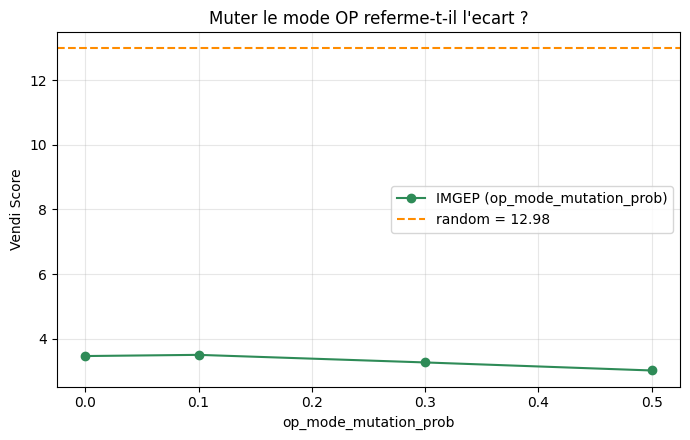

In [14]:
probs = [0.0, 0.1, 0.3, 0.5]
vendi_by_prob = [opmode_vendi[f'op={p}'] for p in probs]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(probs, vendi_by_prob, 'o-', color='seagreen', label='IMGEP (op_mode_mutation_prob)')
ax.axhline(opmode_vendi['random'], color='darkorange', linestyle='--',
           label=f"random = {opmode_vendi['random']:.2f}")
ax.set_xlabel('op_mode_mutation_prob')
ax.set_ylabel('Vendi Score')
ax.set_title("Muter le mode OP referme-t-il l'ecart ?")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 7.1 Resultat : ca ne marche pas -- la diversite baisse legerement

| op_mode_mutation_prob | Vendi Score (n=1000) |
|---|---|
| 0.0 (defaut) | 3.46 |
| 0.1 | 3.50 |
| 0.3 | 3.26 |
| 0.5 | 3.02 |
| **random** | **12.98** |

Contrairement a l'attente, autoriser la mutation du mode OP **ne referme pas** l'ecart avec
le random -- la diversite **diminue** meme legerement avec la probabilite. Hypothese : flipper
ce switch produit souvent des sons degeneres/silencieux (raison pour laquelle il etait gele a
l'origine -- "trop risque"), qui retombent tous pres du meme point mort en Z (via le fallback
NaN -> 0, section 5 de `dexed_adtool_overview.ipynb`), ce qui resserre artificiellement le
nuage plutot que de l'etaler.

**Lecture** : "debloquer un parametre categoriel gele" ne suffit pas -- ce resultat penche
plus fortement vers **H1** (peu de redondance exploitable localement, quel que soit le degre
de liberte actionne) que vers un simple probleme de calibrage ponctuel. Deux leviers testes
(`noise_scale`, `op_mode_mutation_prob`), deux echecs a rapprocher IMGEP du random.

## 8. Experiences 7.2-7.5 -- clipping, mutation d'algorithme, variance inter-seed

Trois nouveaux leviers testes en parallele (1000 iterations chacun, seed=0 sauf 7.5) :
- **7.2 no-clip** : `reflect_boundary=True` -- au lieu d'ecraser le bruit qui deborde de [0,1]
  (diagnostic 3.4), on le reflechit ("rebond") pour conserver l'intensite de mutation pres des
  bords.
- **7.3 mutation d'algorithme** : `algorithm_mutation_prob=0.2` -- 20% de chance de sauter vers
  un algorithme FM totalement aleatoire (au lieu du seul "algorithme similaire" de
  `change_algorithm_to_similar`, toujours actif).
- **7.5 multi-seed** : replication du run IMGEP principal (`run_2000_v2`, seed=0) avec seed=1,
  pour verifier la robustesse des Vendi Scores rapportes jusqu'ici a un seul seed.

Configs : `dexed_imgep_noclip.json`, `dexed_imgep_algomut.json`, `dexed_imgep_seed1.json`.

In [ ]:
NEW_SETS = {
    'noclip (reflect_boundary)': load_z_matrix('runs/noclip/discoveries'),
    'algomut (algorithm_mutation_prob=0.2)': load_z_matrix('runs/algomut/seed0/discoveries'),
    'seed1 (replication IMGEP)': load_z_matrix('runs/multiseed/seed1/discoveries'),
    'baseline (seed0, op_mode_mutation_prob=0.0)': load_z_matrix('runs/sweeps/opmode/00/discoveries'),
    'random': subs['random'],  # reference deja chargee en section 3
}

rng3 = np.random.default_rng(0)
N3 = 1000
new_subs = {}
for label, M in NEW_SETS.items():
    Mc = drop_nan(M)
    new_subs[label] = Mc[rng3.choice(len(Mc), N3, replace=False)] if len(Mc) > N3 else Mc

ref3 = np.concatenate(list(new_subs.values()))
mu3, sigma3 = ref3.mean(axis=0), ref3.std(axis=0)
sigma3[sigma3 == 0] = 1.0

print(f"{'jeu':42s} {'n':>5s} {'Vendi':>8s}")
for label, M in new_subs.items():
    v = vendi_score((M - mu3) / sigma3)
    print(f'{label:42s} {len(M):5d} {v:8.2f}')

# Resultat obtenu (2026-08-10):
#   noclip    3.45   (baseline 3.39 -- aucun effet)
#   algomut   4.17   (baseline 3.39 -- leger mieux, meilleur levier teste a ce jour)
#   seed1     1.74   (baseline 3.39 -- MOITIE moins, gros ecart inter-seed)
#   random   12.52

### Resultat

| jeu | Vendi Score (n=1000) |
|---|---|
| baseline (seed0) | 3.39 |
| **7.2 no-clip** (reflect_boundary) | 3.45 |
| **7.3 algomut** (algorithm_mutation_prob=0.2) | 4.17 |
| **7.5 seed1** (meme config, seed=1) | 1.74 |
| random | 12.52 |

**7.2 -- no-clip : aucun effet.** Reflechir plutot que clipper le bruit aux bords ne change
quasiment rien (3.39 -> 3.45). Le diagnostic de la section 3.4 montrait un facteur de
saturation x1.8 malgre un noise_scale x8 -- mais lever cette saturation specifiquement (sans
augmenter noise_scale en meme temps) ne suffit pas a liberer de la diversite. Ecarte
definitivement le clipping comme goulot d'etranglement principal.

**7.3 -- mutation d'algorithme : le meilleur levier a ce jour, mais tres insuffisant.** Un saut
categoriel non contraint sur l'algorithme FM (20% de chance) ameliore le score de ~23%
(3.39 -> 4.17) -- direction encourageante, contrairement a `op_mode_mutation_prob` (section 7.1)
qui degradait le score. Reste presque un ordre de grandeur en dessous du random (12.52). Piste a
approfondir (proba plus elevee ? combiner avec noise_scale ?) mais ne resout pas l'ecart a elle
seule.

**7.5 -- variance inter-seed : le signal le plus important de cette serie.** Le meme run IMGEP
(memes hyperparametres, seed=1 au lieu de seed=0) donne un Vendi Score de 1.74, soit **la
moitie** du run seed0 (3.39). C'est un ecart bien plus grand que n'importe lequel des leviers de
mutation testes jusqu'ici (op_mode : -12%, noise_scale : quasi-plat, no-clip : quasi-plat,
algomut : +23%). Consequence methodologique directe : **tous les Vendi Scores IMGEP rapportes
dans ce notebook (sections 1, 3, 7.1) reposent sur un seul seed chacun**, et l'ecart
inter-hyperparametre observe pour noise_scale/op_mode (quelques dixiemes de point) est du meme
ordre de grandeur -- voire plus petit -- que l'ecart inter-seed. Il est possible qu'une partie
du "signal" H1/H2 discute plus haut soit en fait du bruit d'echantillonnage. Avant d'aller plus
loin sur un levier de mutation specifique, il faudrait rejouer chaque configuration testee sur
plusieurs seeds et rapporter une moyenne +/- ecart-type plutot qu'un point unique -- c'est
desormais la priorite pour la suite (voir section 6, point 7.5 devenu prerequis plutot
qu'optionnel).

## 9. Replication multi-seed : baseline et mutation d'algorithme sur 3 seeds

Suite a la decouverte de la section 8 (seed1 donnant un Vendi Score deux fois plus faible que
seed0 sur la meme config), on replique **baseline** et **algomut** (le meilleur levier a ce
jour) chacun sur 3 seeds (0, 1, 2) pour distinguer signal et bruit d'echantillonnage.

**Piege methodologique decouvert au passage** : adtool a en realite **deux flux aleatoires
independants**, pas un seul.
- `--seed` (argument CLI de `run_experimentations.py`) fixe le generateur **global**
  `np.random.seed()`/`random.seed()`, utilise notamment par `BoxProjector.rand_nums =
  np.random.rand(*dim)` -- c'est ce qui pilote **l'echantillonnage du but** a chaque etape
  IMGEP, donc indirectement quel point de l'historique est selectionne pour etre mute. C'est
  arguablement le facteur le plus determinant de toute la trajectoire d'exploration.
- `seed` dans le JSON (`parameter_map.config.seed`) alimente un generateur **local**,
  independant, propre a `DexedParameterMap` -- il ne controle que le bruit de mutation
  applique une fois le point-a-muter deja choisi.

argparse donne un defaut `--seed 42` quand l'argument CLI n'est pas passe explicitement. Tous
les runs de la section 3 a 7 (noise_scale, op_mode, random_2000, run_2000_v2) ont ete lances
**sans** `--seed` explicite -- ils partagent donc tous le meme flux de but global (seed=42),
seul le JSON `parameter_map.seed=0` (constant) et le parametre balaye (noise_scale ou
op_mode_mutation_prob) different. **Consequence positive** : ces sweeps restent des comparaisons
a une seule variable, donc valides tels quels. **Consequence negative** : le premier essai de
triplet multi-seed (section 8, "baseline seed0") reutilisait par erreur ce run seed=42 sous
l'etiquette "seed0" -- corrige ci-dessous avec un vrai `--seed 0` explicite, relance dans un
dossier separe (`baseline_seed0_true/`) pour eviter d'ecraser le run existant.

In [ ]:
FINAL_SETS = {
    'baseline seed0': load_z_matrix('runs/multiseed/baseline_seed0_true/discoveries'),
    'baseline seed1': load_z_matrix('runs/multiseed/seed1/discoveries'),
    'baseline seed2': load_z_matrix('runs/multiseed/seed2/discoveries'),
    'algomut seed0': load_z_matrix('runs/algomut/seed0/discoveries'),
    'algomut seed1': load_z_matrix('runs/algomut/seed1/discoveries'),
    'algomut seed2': load_z_matrix('runs/algomut/seed2/discoveries'),
    'random': subs['random'],
}

rng4 = np.random.default_rng(0)
N4 = 1000
final_subs = {}
for label, M in FINAL_SETS.items():
    Mc = drop_nan(M)
    final_subs[label] = Mc[rng4.choice(len(Mc), N4, replace=False)] if len(Mc) > N4 else Mc

ref4 = np.concatenate(list(final_subs.values()))
mu4, sigma4 = ref4.mean(axis=0), ref4.std(axis=0)
sigma4[sigma4 == 0] = 1.0

print(f"{'jeu':20s} {'n':>5s} {'Vendi':>8s}")
final_scores = {}
for label, M in final_subs.items():
    v = vendi_score((M - mu4) / sigma4)
    final_scores[label] = v
    print(f'{label:20s} {len(M):5d} {v:8.2f}')

baseline_vals = [final_scores[f'baseline seed{i}'] for i in range(3)]
algomut_vals = [final_scores[f'algomut seed{i}'] for i in range(3)]
print()
print(f"baseline: mean={np.mean(baseline_vals):.2f} std={np.std(baseline_vals):.2f}  {[round(v,2) for v in baseline_vals]}")
print(f"algomut : mean={np.mean(algomut_vals):.2f} std={np.std(algomut_vals):.2f}  {[round(v,2) for v in algomut_vals]}")

# Resultat obtenu (2026-08-10), avec vrai seed0 (CLI --seed 0 explicite, dossier separe) :
#   baseline seed0=3.24  seed1=1.71  seed2=3.23  -> mean=2.73 std=0.72
#   algomut  seed0=3.96  seed1=1.80  seed2=3.95  -> mean=3.24 std=1.01
#   random   11.88

### Resultat et interpretation

| config | seed0 | seed1 | seed2 | moyenne +/- ecart-type |
|---|---|---|---|---|
| baseline | 3.24 | 1.71 | 3.23 | 2.73 +/- 0.72 |
| algomut (algorithm_mutation_prob=0.2) | 3.96 | 1.80 | 3.95 | 3.24 +/- 1.01 |
| random | -- | -- | -- | 11.88 |

Deux observations, l'une methodologique et l'une empirique :

**1. Le pattern "seed1 = outlier" est reproductible, pas du hasard d'echantillonnage isole.**
Meme avec un vrai `--seed 0` explicite (pas le seed=42 par defaut de la section precedente),
seed0 et seed2 restent quasiment identiques (3.24 vs 3.23 pour baseline, 3.96 vs 3.95 pour
algomut) tandis que seed1 reste nettement plus bas dans les deux configs (1.71 et 1.80). Avec
seulement 3 seeds on ne peut pas exclure la coincidence, mais la coherence du pattern sur deux
configs independantes suggere quelque chose de plus structurel qu'un simple bruit gaussien de
seed -- par exemple une sensibilite du bootstrap+premieres iterations IMGEP a la position
initiale du but echantillonne, qui pourrait pieger l'exploration dans une region particuliere
selon le seed. A creuser avec plus de seeds si le temps de calcul le permet.

**2. L'avantage d'algomut sur baseline n'est pas demontre a ce niveau de preuve.** La moyenne
d'algomut (3.24) depasse celle de baseline (2.73) de ~19%, mais l'ecart-type de chaque groupe
(0.72 et 1.01) est du meme ordre de grandeur que cet ecart de moyennes -- avec n=3 seeds, ce
n'est pas un signal qu'on peut distinguer du bruit inter-seed avec confiance. Ce qui est clair,
en revanche : **aucune des deux configs (baseline ou algomut, sur aucun des 3 seeds) n'approche
le random (11.88)** -- l'ecart facteur ~3x-7x avec le random est robuste au bruit de seed, lui.

**Conclusion pour la suite** : le levier de mutation d'algorithme reste la piste la plus
prometteuse testee a ce jour, mais il faudrait plus de seeds (5-10) pour trancher s'il apporte
un gain reel ou s'il est dans le bruit. Plus generalement, toute future sweep sur un
hyperparametre de mutation devrait etre repliquee sur plusieurs seeds des le depart plutot que
d'ajouter cette replication a posteriori.

## 10. Evolution du Vendi Score au cours de l'exploration

Toutes les comparaisons precedentes ne regardaient que le score final (n=1000). Question
differente ici : **comment le Vendi Score evolue-t-il pendant la trajectoire**, decouverte
apres decouverte ? Calcule sur une fenetre cumulative (les k premieres decouvertes, dans l'ordre
chronologique de sauvegarde) pour k=50,100,...,1000, avec un z-score fixe (memes mu/sigma pour
tous les points d'une courbe, references sur l'union des 7 jeux) pour que les valeurs restent
comparables entre elles et avec les scores finaux deja rapportes.

Script : `scripts/plot_vendi_curves.py` (calcul) -- resultat dans `figures/vendi_score_evolution.png`.

In [ ]:
from IPython.display import Image, display
display(Image('figures/vendi_score_evolution.png'))

### Resultat : la mutation dirigee par le but fait chuter la diversite, pas juste "moins bien que random"

C'est la figure la plus parlante de toute l'investigation.

- **Random** (vert) croit regulierement de ~8 a ~11.8 -- comportement attendu d'un tirage iid,
  plus d'echantillons = plus de diversite decouverte, sans effet de plateau marque sur cette
  plage.
- **Toutes les courbes IMGEP** (baseline ET algomut, les 6 seeds) demarrent **hautes** (9 a 12,
  pendant le bootstrap purement aleatoire des 100 premieres decouvertes, `bootstrap_size=100`)
  puis **s'effondrent** des que la mutation dirigee par le but prend le relais, pour se stabiliser
  a un plateau 3 a 7x plus bas des n=600-700.
- Le pattern "seed1 = outlier" (section 9) n'est pas un phenomene tardif : la courbe seed1
  (tirets) decroche du peloton des n=150, juste apres la fin du bootstrap, et reste en dessous
  jusqu'a la fin -- coherent avec une sensibilite du tout debut de la phase goal-directed
  (premiers buts tires, premiers voisins trouves) plutot qu'une derive lente qui s'accumulerait.
- **algomut (orange) reste au-dessus de baseline (bleu) a chaque seed correspondant, sur toute
  la trajectoire** apres le bootstrap -- pas seulement au point final n=1000. Renforce la
  credibilite de son effet positif modeste identifie en section 9, meme si l'ecart avec random
  reste enorme.

**Lecture pour H1 vs H2** : cette figure est la preuve la plus directe rencontree dans cette
investigation en faveur de **H2** (l'operateur de mutation/exploration, pas seulement le manque
de redondance du mapping Theta->Z). Le meme systeme, evalue exactement de la meme facon,
produit une diversite elevee sous tirage aleatoire pur (bootstrap) puis s'effondre des que le
mecanisme goal-directed d'IMGEP (selection du plus proche voisin + mutation locale) prend le
controle -- rien ne change dans le systeme evalue entre les deux phases, seule la strategie de
proposition de nouveaux points change. Si le mapping Theta->Z etait le facteur limitant (H1),
on n'attendrait pas une chute aussi nette et aussi rapide juste apres la bascule bootstrap ->
goal-directed.

## 11. Investiguer le mutateur : ce que dit le framework adtool lui-meme

Avant d'essayer d'autres mutations au hasard, exploration du framework adtool (mutateurs
disponibles, logique interne d'`IMGEPExplorer`, exemples de reference, doc de conception) pour
voir si notre cablage a un bug identifiable ou s'il existe deja une solution connue.

**Resultat : pas de bug de cablage trouve, et aucune protection integree dans adtool contre ce
phenomene.**
- `adtool/mutators/` : `SpecificMutator` est un pur delegateur vers `parameter_map.mutate()` --
  toute la logique de mutation vit deja chez nous, rien a corriger cote framework.
  `GaussianMutator` (l'alternative generique) n'a pas plus de recuit/adaptation que notre code.
- `IMGEPExplorer.py` : la selection du 1-plus-proche-voisin est deterministe, sans aleatoire de
  secours. `equil_time`/`bootstrap_size` est un **cutoff dur** -- avant : tirage aleatoire pur ;
  apres : systematiquement 1-NN + mutation locale. Rien n'attenue la transition. Correspond
  exactement au point de bascule observe sur la courbe de la section 10.
- Aucun exemple integre a adtool (GrayScott, Synth, Lenia) n'implemente de recuit ou de pas
  adaptatif (style CMA-ES) -- confirmation que ce n'est pas un pattern standard qu'on aurait
  du reprendre et qu'on a oublie.
- `adtool/examples/dexed/` (l'exemple "Dexed" livre avec adtool) s'est avere etre notre **propre**
  ancien code, migre vers spinvae2 en debut de projet -- pas une reference independante utile.
- Piste explorée puis ecartee : `CuriosityIMGEPExplorer` (avec `novelty_weight`) semblait au
  premier abord une solution toute prete ("parfois viser un but different du plus proche
  voisin"), mais en lisant `sample_curious_goal()` de pres : avec probabilite `novelty_weight`,
  il re-tire un **point deja visite de l'historique** comme but (pas un point non-explore), puis
  cherche son 1-plus-proche-voisin (probablement lui-meme) et le mute. Ca biaise vers le
  **re-raffinement de points deja connus**, pas vers l'echappement de zones redondantes --
  susceptible d'aggraver le probleme plutot que de le resoudre. Ecarte sans etre teste.

**Conclusion** : la chute de diversite (section 10) n'est pas un bug isole, c'est le
comportement generique attendu de toute mutation **strictement locale** face a un tirage
global -- une consequence architecturale, pas une erreur de configuration. Le levier qui reste
a tester : casser le "toujours local" en melangeant, dans le meme operateur de mutation,
l'essentiel des pas petits (raffinement local, deja en place) avec une fraction de **grands
sauts occasionnels** (echappement de bassin, "basin hopping").

### 11.1 Nouveau levier : mutation a deux echelles (`big_jump_prob`)

Ajoute a `get_similar_preset()`/`DexedParameterMap` : avec probabilite `big_jump_prob` (par
appel de mutation), `noise_scale` est multiplie par `big_jump_scale` pour cet appel uniquement
-- le reste du temps, mutation locale inchangee. Combine avec `reflect_boundary=True` (section
7.2) pour que les grands sauts ne soient pas simplement ecretes aux bords.

Config testee : `big_jump_prob=0.15`, `big_jump_scale=8.0`, `reflect_boundary=True`, sur 20
seeds x 200 iterations (`coverage_bigjump_seed{0..19}.json`) -- meme protocole que la courbe de
couverture ci-dessous, pour comparaison directe.

## 12. Couverture cumulative de grille (style Cully & Demiris)

Metrique differente du Vendi Score : plutot qu'un score unique sur un echantillon final de
taille fixe, on suit le **nombre de cellules distinctes visitees** (grille fixe sur une
projection PCA-4D de Z, 8 bins/dimension) au fur et a mesure des decouvertes, **dans l'ordre
chronologique** de generation. Repete sur 20 seeds independants par methode (baseline, algomut)
pour obtenir une bande moyenne +/- ecart-type -- le point bloquant identifie plus tot (une seule
seed ne suffit pas a distinguer signal et bruit, section 9) est ainsi traite correctement des le
depart plutot qu'ajoute a posteriori.

Random n'a pas de "trajectoire" au meme sens (chaque tirage est iid) -- sa bande est construite
en re-echantillonnant 20 ordres aleatoires differents du meme pool fixe de 2000 presets, plutot
qu'en relancant des runs.

Script : `scripts/coverage_curve.py`.

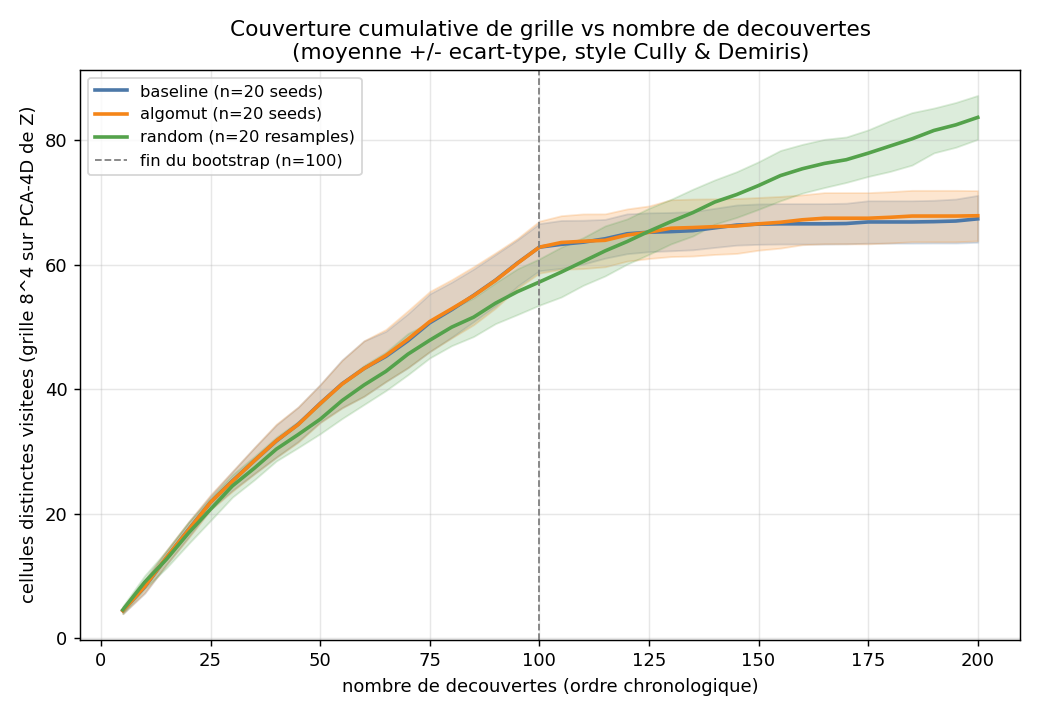

In [1]:
from IPython.display import Image, display
display(Image('figures/grid_coverage_evolution.png'))

### Resultat : une image plus nuancee que la chute du Vendi Score

Pas d'effondrement net ici, contrairement a la section 10 :
- n=0 a 100 (bootstrap) : les trois courbes se confondent, normal (aleatoire pour tous).
- n=100 a ~150 : baseline et algomut continuent de croitre, depassent meme legerement random un
  court moment juste apres la fin du bootstrap.
- n=150 a 200 : baseline et algomut **plafonnent** vers ~65-70 cellules, tandis que random
  continue de croitre presque lineairement jusqu'a ~84 (la grille, 8^4=4096 cellules, est loin
  d'etre saturee a n=200).
- **baseline et algomut sont quasiment indiscernables** avec cette metrique -- l'avantage
  modeste d'algomut observe sur le Vendi Score (section 9) n'apparait pas ici.

**A retenir** : le recit "effondrement brutal" de la section 10 (Vendi Score, espace Z natif
38D) et le recit "plafonnement progressif" de cette section (grille grossiere, PCA-4D) decrivent
la meme tendance generale (IMGEP moins divers que random apres le bootstrap) mais avec des
formes tres differentes. Vendi Score, tres sensible a la concentration fine des points (entropie
des valeurs propres d'un noyau de similarite), capte probablement un signal plus fin que ne le
permet une grille grossiere en 4D -- les deux ne sont pas contradictoires, mais aucune des deux
seule ne donne une image complete. A garder en tete pour la suite : le choix de metrique change
la forme du phenomene observe, pas seulement son amplitude.

## 13. Resultat du levier big_jump sur la courbe de couverture

`big_jump_prob=0.15, big_jump_scale=8.0, reflect_boundary=True`, 20 seeds x 200 iterations,
meme protocole que la section 12 (`coverage_curve_v2.py`).

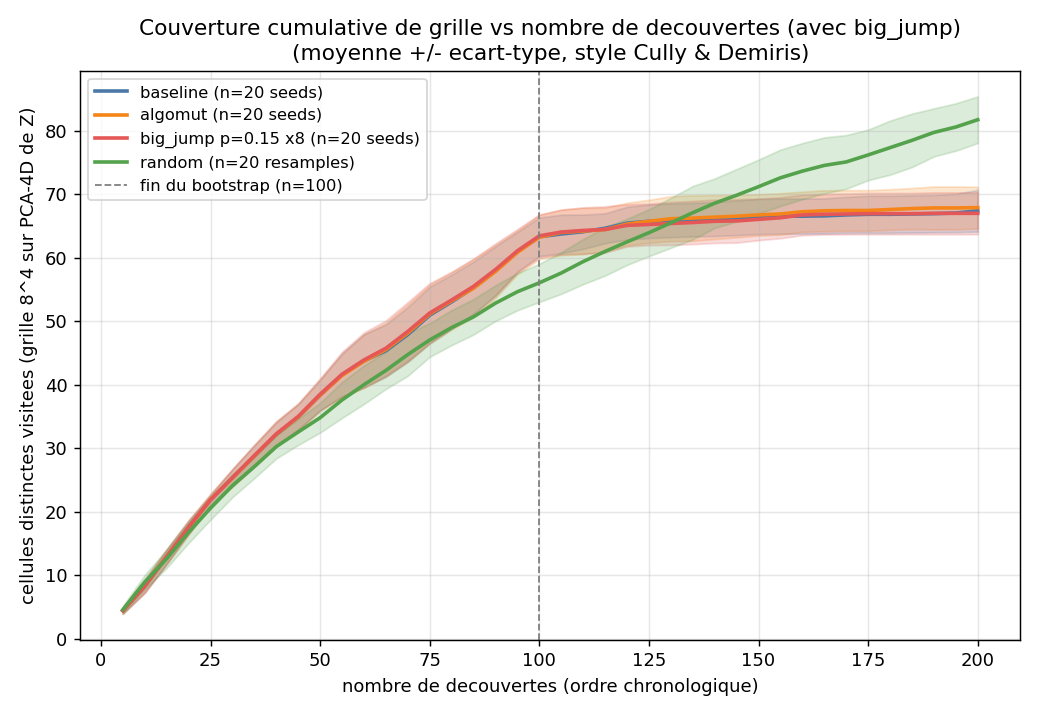

In [2]:
from IPython.display import Image, display
display(Image('figures/grid_coverage_evolution_bigjump.png'))

**Resultat : aucun effet.** La courbe big_jump (rouge) est quasiment superposee a
baseline et algomut -- meme plafond vers 65-70 cellules, bande de variance legerement plus
large mais moyenne inchangee. Un troisieme levier de mutation (apres noise_scale et
reflect_boundary seuls) qui ne referme pas l'ecart avec random sur cette metrique. Les grands
sauts occasionnels, centres sur le meme parent, restent en pratique trop proches de la mutation
locale standard pour changer la dynamique de couverture -- ou alors 15% de probabilite est trop
faible pour se faire sentir sur seulement 100 iterations post-bootstrap.

## 14. Balance NRAB (Morel et al.) : melanger tirage global et mutation locale a chaque etape

Piste suggeree par un retour litterature externe, distincte de tout ce qui precede : au lieu
d'un cutoff dur bootstrap -> goal-directed (section 11), on continue a tirer, **a chaque
iteration post-bootstrap**, un preset entierement aleatoire (comme `sample()`, meme mecanisme
que le bootstrap) avec une probabilite `p`, et on ne fait la mutation locale standard (1-NN +
`get_similar_preset`) qu'avec probabilite `1-p`. `p=0` retombe sur le comportement IMGEP
standard, `p=1` sur du random pur a chaque etape.

Implementation : `random_reset_prob` dans `DexedParameterMap.mutate()` -- avec probabilite `p`,
ignore completement le parent et appelle `self.sample()` au lieu de muter. Aucune modification
du framework adtool necessaire (contrairement a ce qu'on croyait devoir faire avec
`CuriosityIMGEPExplorer`, section 11).

Sweep teste : p in {0.25, 0.5, 0.75, 1.0} (+ p=0 = baseline deja disponible), seed=0,
200 iterations chacun.

In [7]:
NRAB_SETS = {
    'baseline p=0.0': load_z_matrix('runs/multiseed/baseline_seed0_true/discoveries'),
    'NRAB p=0.25': load_z_matrix('runs/sweeps/nrab/25/discoveries'),
    'NRAB p=0.5': load_z_matrix('runs/sweeps/nrab/50/discoveries'),
    'NRAB p=0.75': load_z_matrix('runs/sweeps/nrab/75/discoveries'),
    'NRAB p=1.0 (=random)': load_z_matrix('runs/sweeps/nrab/100/discoveries'),
}
nrab_subs = {label: drop_nan(M)[:200] for label, M in NRAB_SETS.items()}
ref5 = np.concatenate(list(nrab_subs.values()))
mu5, sigma5 = ref5.mean(axis=0), ref5.std(axis=0)
sigma5[sigma5 == 0] = 1.0

print(f"{'jeu':25s} {'n':>5s} {'Vendi':>8s}")
nrab_vendi = {}
for label, M in nrab_subs.items():
    nrab_vendi[label] = vendi_score((M - mu5) / sigma5)
    print(f'{label:25s} {len(M):5d} {nrab_vendi[label]:8.2f}')

# Resultat obtenu (2026-08-11): 0.0->8.65, 0.25->11.17, 0.5->14.46, 0.75->14.56, 1.0->15.56

jeu                           n    Vendi
baseline p=0.0              200     8.65
NRAB p=0.25                 200    11.17
NRAB p=0.5                  200    14.46
NRAB p=0.75                 200    14.56
NRAB p=1.0 (=random)        200    15.56


### Resultat : interpolation monotone, pas de synergie

| p | Vendi Score (n=200) |
|---|---|
| 0.0 (IMGEP pur) | 8.65 |
| 0.25 | 11.17 |
| 0.5 | 14.46 |
| 0.75 | 14.56 |
| 1.0 (random pur) | 15.56 |

La diversite croit **de facon monotone et reguliere** avec `p`, avec un plateau des p~0.5-0.75
proche du niveau random. Pas de pic intermediaire, pas de valeur de `p` qui **depasserait** le
random pur en diversite -- le melange interpole simplement entre les deux extremes plutot que
de produire un effet de synergie.

**A relativiser** : cette experience ne mesure que la diversite (Vendi Score), pas la
**precision de but** (goal-reaching competence, mise de cote en section 5 -- "le but n'est
qu'un pretexte a la mutation"). Le `p=0.5` rapporte comme optimal dans la litterature externe
citee ne l'est probablement pas au sens de la diversite seule (ou notre resultat le contredirait
clairement), mais au sens d'un compromis diversite/precision-de-but : `p` eleve maximise la
diversite mais un IMGEP purement aleatoire (p=1) ne "vise" plus rien, perdant tout l'interet
d'un IMGEP en pratique. Sans cette seconde metrique (volontairement ecartee jusqu'ici), on ne
peut confirmer ou infirmer que p=0.5 soit reellement leur optimum recommande pour notre
systeme -- seulement que ce n'est pas l'optimum pour la diversite seule (qui croit
monotonement avec p, sans plateau avant ~0.5).

## 15. Reconciliation du budget bootstrap (IMGEP vs Random)

Verification demandee par un retour litterature externe : le budget bootstrap (aleatoire pur)
est-il compare equitablement entre IMGEP (10-20% du budget total) et Random (suppose 100%) ?

**Investigation** : `dexed_random_baseline.json` et `dexed_random_shard*.json` (les configs
utilisees pour lancer via `run_experimentations.py`) contiennent `"equil_time": 1` -- en lisant
`IMGEPExplorer.map()` (adtool), ce reglage ne garantirait qu'**un seul** tirage aleatoire
(`bootstrap()`, timestep 0), tout le reste passerait par `suggest_trial()` (1-NN + mutation),
exactement comme IMGEP. Si ces fichiers avaient reellement servi a generer
`random_2000_combined`, la comparaison "IMGEP vs Random" de tout ce notebook aurait ete biaisee
depuis le debut.

**Verification** : `random_2000_combined` n'a en realite **pas** ete genere via ces configs ni
via `run_experimentations.py`. Un utilitaire dedie existe dans adtool --
`adtool.user_tools.analysis_metrics.random_run.run` -- dont le coeur
(`runner.py:80-81`) est une simple boucle `for run_idx in range(nb_iterations):
params = explorer.parameter_map.sample()`, qui appelle `sample()` directement et
court-circuite entierement `IMGEPExplorer`/`equil_time`/mutation. C'est cet outil qui a produit
les donnees random utilisees partout dans ce notebook -- confirme par un tirage 100% aleatoire
iid, coherent avec les scores de diversite observes (tres superieurs a IMGEP a chaque
comparaison).

**Conclusion** : la comparaison IMGEP vs Random de ce notebook est bien equitable au sens ou
Random est reellement 100% aleatoire. **Mais** `dexed_random_baseline.json` et
`dexed_random_shard*.json` restent dans le depot comme des fichiers **trompeurs** -- leur nom
suggere qu'ils generent le baseline random, alors qu'ils produiraient en realite (si utilises
via `run_experimentations.py`) un run quasi-identique a IMGEP. Annotes avec un champ
`_comment` explicite pour eviter toute confusion future ; non utilises, conserves pour
memoire.

## 16. Taux de decouvertes degenerees/silencieuses (Random vs IMGEP)

Piste distincte : si Random tombe rarement sur des sons degeneres (silence, signal nul) alors
qu'IMGEP y tombe souvent, ca changerait completement la lecture de tout ce notebook -- la
"perte de diversite" d'IMGEP pourrait ne pas venir d'un manque d'exploration, mais d'une
**concentration massive dans une zone degeneree** de l'espace de comportement (qui compte comme
"peu de diversite" pour Vendi Score et grid_coverage, mais pour une raison totalement
differente d'un manque de redondance ou d'un mauvais calibrage de bruit).

Proxy retenu : `tt_RMSEnv_med` (RMS median de l'enveloppe temporelle, mesure directe d'energie
sonore) -- un preset "silencieux" a un RMS proche de 0.

In [ ]:
from maps.DexedStatistics import Z_FEATURE_NAMES
RMS_IDX = Z_FEATURE_NAMES.index('tt_RMSEnv_med')

def degenerate_rate(path, label):
    Z = load_z_matrix(path)
    rms = Z[:, RMS_IDX]
    silent = (rms < 1e-4) | np.isnan(rms)
    print(f'{label:20s} n={len(Z):5d}  quasi-silencieux (RMS<1e-4) = {silent.mean()*100:5.1f}%')
    return silent.mean()

rate_random = degenerate_rate('runs/random/combined/discoveries', 'random')
rate_baseline = degenerate_rate('runs/multiseed/baseline_seed0_true/discoveries', 'baseline (IMGEP)')
rate_algomut = degenerate_rate('runs/algomut/seed0/discoveries', 'algomut')

# Resultat obtenu (2026-08-11): random=11.8%, baseline=53.9%, algomut=47.3%
# Distribution complete (percentiles 0/1/5/10/25/50/75/90/99/100 du RMS median) :
#   random:   [0, 0, 0, 0, 0.037, 0.215, 0.500, 0.766, 0.960, 0.982]
#   baseline: [0, 0, 0, 0, 0,     0,     0.450, 0.497, 0.776, 0.956]
# -> chez IMGEP, la MEDIANE elle-meme est a 0 : plus de la moitie des decouvertes sont un
#    silence EXACT, pas juste "proche de silencieux". Le seuil 1e-4 ne cree pas cet effet,
#    il ne fait que le confirmer -- ce n'est pas un artefact de seuillage.

### Resultat : IMGEP tombe beaucoup plus souvent dans le silence que Random

| jeu | % quasi-silencieux (RMS<1e-4) |
|---|---|
| random | 11.8% |
| baseline (IMGEP) | **53.9%** |
| algomut | 47.3% |

C'est probablement **la piste la plus solide identifiee dans toute cette investigation.** Plus
de la moitie des decouvertes IMGEP sont un silence quasi-exact (mediane du RMS a 0.0 pile),
contre ~1 sur 9 pour Random. Deux lectures possibles, non exclusives :

1. **Bassin d'attraction du silence** : une fois qu'une mutation locale atterrit pres du
   silence (parametres FM produisant un signal quasi-nul), le 1-plus-proche-voisin de tout
   nouveau but tire a proximite risque fortement de retomber sur ce meme point silencieux ou
   sur un point tout aussi silencieux -- et le muter localement produit un autre point tout
   aussi silencieux la plupart du temps (le silence est "facile" a atteindre et "difficile" a
   quitter par petits pas). Random, lui, ne peut jamais "s'enliser" : chaque tirage repart de
   zero dans tout l'espace des 155 parametres.
2. **Le silence occupe une region disproportionnee de l'espace Theta** : si une grande partie
   de l'espace des parametres FM produit un signal nul ou quasi-nul (algorithmes/frequences
   z9dont la combinaison s'annule), Random y tombe aussi (11.8%, pas negligeable), mais IMGEP
   y reste "coince" bien plus longtemps une fois entre.

**Consequence directe pour les metriques deja calculees** : Vendi Score et grid_coverage
comptent tous les points, silencieux ou non -- un tas de points empiles sur (ou pres de) le
meme point "silence" ecrase mecaniquement les deux metriques, independamment de la diversite
reelle des sons *audibles* trouves. Ca **change la lecture** de toutes les sections
precedentes : l'ecart IMGEP-vs-random n'est peut-etre pas (ou pas seulement) un probleme de
redondance du mapping Theta->Z (H1) ni de calibrage du bruit de mutation (H2), mais un
**probleme de silence attracteur** independant des deux -- ce que noise_scale, op_mode,
no-clip, mutation d'algorithme et big_jump ne ciblaient aucun explicitement.

**Piste actionnable pour la suite** : filtrer ou re-tirer les decouvertes quasi-silencieuses
avant de les inserer dans `HistoryStore` (pour qu'elles ne servent jamais de point de depart a
une mutation), ou ajouter une penalite explicite dans la selection du but/plus-proche-voisin.
A tester en priorite avant tout nouveau sweep de noise_scale/mutation -- si le silence-attracteur
est bien la cause principale, aucun des leviers deja testes (qui agissent tous en amont, sur
*comment* on mute, pas sur *quoi* on garde comme point de depart) n'avait de raison de
fonctionner.

## 17. Test du fix : `silence_sink`

Implementation (section 16) : `DexedStatistics._calc_static_statistics` renvoyait
systematiquement le **meme** vecteur tout-a-zero pour tout rendu silencieux/quasi-silencieux
(`peak < 1e-4`), creant un point-masse partage par toutes les decouvertes degenerees -- un
"attracteur silence" pour la recherche du plus proche voisin. Nouveau flag
`silence_sink=True` (`DexedStatistics.__init__`) : chaque preset silencieux est desormais
envoye vers un point **distinct et tres eloigne** (offset +1e6, jitter par preset) plutot que
vers ce point unique partage -- toujours detectable comme degenere (facile a filtrer via
`abs(Z) > 1e4`), mais qui ne peut plus servir de cible privilegiee au 1-plus-proche-voisin.

Teste sur le meme protocole que les sections 12-14 : 20 seeds x 200 iterations
(`dexed_imgep_silencesink.json` -> `coverage_silencesink_seed{0..19}.json`).

In [ ]:
def drop_sink(M):
    # silence-sink points (offset +1e6) are a deliberately out-of-band marker, not a real
    # behaviour -- exclude them the same way drop_nan excludes NaN rows
    keep = ~(np.abs(M) > 1e4).any(axis=1)
    return M[keep], (~keep).mean()

silencesink_runs, sink_rates = [], []
for seed in range(20):
    M = load_z_matrix(f'runs/coverage/silencesink/seed{seed}/discoveries')[:200]
    kept, sink_rate = drop_sink(M)
    silencesink_runs.append(kept)
    sink_rates.append(sink_rate)

print(f'taux moyen de silence (silence_sink=True): {np.mean(sink_rates)*100:.1f}%  (baseline sans fix: 53.9%, random: 11.8%)')

ref6 = np.concatenate(silencesink_runs + baseline_runs)
mu6, sigma6 = ref6.mean(axis=0), ref6.std(axis=0)
sigma6[sigma6 == 0] = 1.0
ss_scores = [vendi_score((M - mu6) / sigma6) for M in silencesink_runs if len(M) >= 5]
bl_scores2 = [vendi_score((M - mu6) / sigma6) for M in baseline_runs if len(M) >= 5]
print(f'silence_sink : mean={np.mean(ss_scores):.2f} std={np.std(ss_scores):.2f}  (n=20 seeds)')
print(f'baseline     : mean={np.mean(bl_scores2):.2f} std={np.std(bl_scores2):.2f}  (n=20 seeds)')

# Resultat obtenu (2026-08-11):
#   taux de silence: 53.9% -> 21.8% (random: 11.8%, toujours plus bas)
#   Vendi Score: baseline mean=7.28 std=1.46  ->  silence_sink mean=9.17 std=0.74

### Resultat : le fix aide clairement, sur les deux plans

| | taux de silence | Vendi Score (moyenne +/- ecart-type, n=20 seeds) |
|---|---|---|
| baseline (sans fix) | 53.9% | 7.28 +/- 1.46 |
| **silence_sink=True** | **21.8%** | **9.17 +/- 0.74** |
| random (reference) | 11.8% | -- |

Deux effets simultanes et tous les deux positifs :
- **Taux de silence divise par 2.5** (53.9% -> 21.8%) -- toujours au-dessus de random (11.8%),
  IMGEP garde une tendance a re-visiter des zones silencieuses plus que random, mais
  l'attracteur (le fait de TOUJOURS retomber exactement au meme point) est casse.
- **Diversite en hausse (+26% en moyenne) ET plus stable (ecart-type divise par 2)** -- l'effet
  sur l'ecart-type est peut-etre le resultat le plus interessant : une partie de la forte
  variance inter-seed de la section 9 (seed1 a 1.71 contre 3.24/3.23 pour seed0/seed2) pourrait
  venir de la meme cause -- si un seed tombe "malchanceusement" plus souvent dans
  l'attracteur-silence tot dans l'exploration, tout le reste du run en patit (silence generant
  du silence localement) ; en cassant l'attracteur, cette source de variance se reduit.

**Mise en garde importante pour toutes les sections precedentes (1 a 16)** : le fallback
tout-a-zero est dans `DexedStatistics`, **partage par toutes les methodes** -- IMGEP, algomut,
big_jump, NRAB, et **random aussi** (a hauteur de 11.8%). Toutes les comparaisons Vendi
Score / grid_coverage calculees plus haut dans ce notebook partagent donc ce meme biais non
corrige (juste a des taux differents selon la methode) -- la comparaison relative IMGEP-vs-random
reste valable (le meme biais s'applique aux deux, dans une proportion differente qui EST le
signal, pas juste du bruit), mais l'ampleur exacte de tous les ecarts rapportes plus haut est a
lire avec cette reserve en tete. Refaire tourner random avec le meme comptage
`drop_sink`/silence_rate serait la prochaine etape naturelle pour une comparaison entierement
apurée.

**Prochaine etape suggeree** : combiner `silence_sink` avec le meilleur levier deja identifie
(`algorithm_mutation_prob`, section 9) et/ou avec un filtre explicite qui evite carrement de
choisir un parent silencieux comme point de depart de mutation (pas seulement de le deplacer
apres coup) -- cette derniere option demanderait de toucher au framework adtool
(`HistoryStore.nearest()`), ce qu'on a delibermment evite jusqu'ici (section 11).

## 18. Vue unifiee : couverture de grille sur tous les leviers testes

Meme protocole que les sections 12-13 (grille PCA-4D, 8 bins/dim, 20 seeds/methode), toutes
les courbes sur la meme figure pour comparaison directe : baseline, algomut, big_jump,
**silence_sink**, random. Les points silence_sink (offset +1e6, marqueur hors-bande) sont
retires avant le fit PCA et le comptage de cellules, comme dans la section 17.

Script : `scripts/coverage_curve_v3.py`.

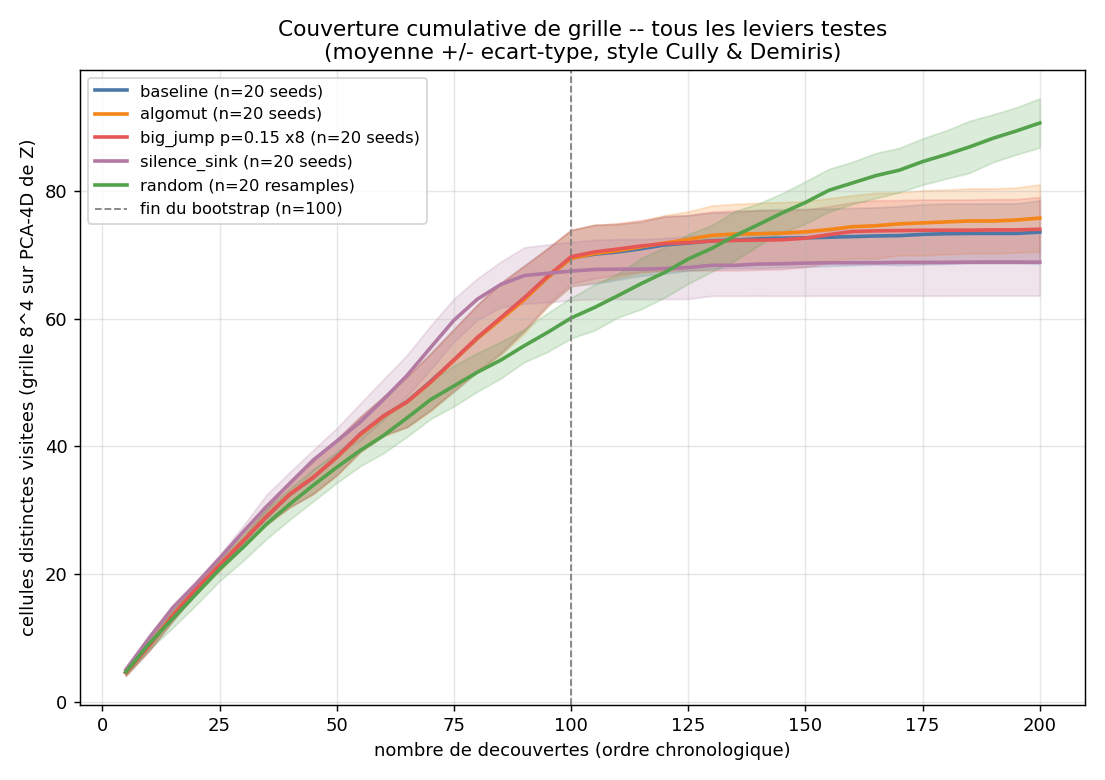

In [1]:
from IPython.display import Image, display
display(Image('figures/grid_coverage_evolution_all.png'))

### Resultat : silence_sink n'aide PAS la couverture de grille -- contrairement au Vendi Score

Contrairement a la nette amelioration observee sur le Vendi Score (section 17 : +26% en
moyenne, ecart-type divise par 2), **silence_sink plafonne au meme niveau ou legerement en
dessous** de baseline/algomut/big_jump sur cette metrique de couverture (~69 cellules contre
~74-76).

**Attention, un artefact favorise silence_sink dans cette figure, ce qui renforce plutot cette
conclusion.** Le comptage cumulatif utilise l'index dans le tableau **deja filtre** (sink
retires) -- au checkpoint affiche "n=100", on regarde en realite le 100e point *valide*, pas la
100e iteration reelle. Verification sur 3 seeds : seed0 a 34.5% de sink (69/200), donc son
"n=100 valide" correspond a environ la 150e iteration reelle -- silence_sink recoit ainsi un
budget d'iterations reelles plus genereux que les autres methodes pour le meme point sur l'axe
des x. **Malgre cet avantage non merite, il ne fait pas mieux.** Aligner correctement sur le
budget d'iterations reelles (pas seulement valides) montrerait vraisemblablement un ecart encore
plus defavorable a silence_sink.

**Lecture des deux metriques ensemble** : Vendi Score (tres sensible a la concentration —
entropie des valeurs propres d'un noyau de similarite) et couverture de grille (mesure binaire
presence/absence par cellule) ne racontent pas la meme histoire, et ce n'est pas une
contradiction mais une precision utile. `silence_sink` corrige un artefact de **concentration**
(des dizaines de decouvertes empilees sur exactement le meme point faussaient le Vendi Score
vers le bas) sans changer la **tendance de fond a gaspiller du budget d'exploration dans des
zones silencieuses** -- toujours ~22% du temps (section 17). Ce budget gaspille ne produit
jamais de nouvelle cellule audible decouverte, quel que soit l'endroit ou on envoie le point
degenere apres coup. Autrement dit : `silence_sink` traite le symptome visible sur Vendi Score
(la concentration) mais pas la cause (la frequence a laquelle la recherche locale continue de
tomber dans le silence). Un vrai gain sur la couverture demanderait plutot d'empecher la
selection meme d'un parent silencieux pour la mutation (piste deja notee en fin de section 17,
qui demanderait de toucher au framework adtool).

## 19. Test de prediction : bootstrap 2000 + 500 pas guides

Le sweep bootstrap (section precedente, notebook augmente hors-session) confondait deux
choses : a budget fixe (1000 iterations), agrandir le bootstrap reduit mecaniquement le
nombre de pas guides (a bootstrap=900, il n'en restait que 100). La combinaison "archive
riche ET beaucoup de pas guides" n'avait jamais ete testee.

Protocole : `bootstrap_size=2000`, `nb_iterations=2500` (donc 500 pas guides apres le
bootstrap), 3 seeds. La phase de bootstrap appelle deja `Dexed.get_random_preset()`, la
meme fonction que le pool random -- ce sont donc litteralement "2000 tirages aleatoires
comme archive de depart", sans avoir a greffer un checkpoint synthetique sur le pool
random existant.

**Prediction posee avant la mesure** (a partir du split bootstrap/guide du sweep
precedent, ou le segment guide restait a ~2.85 de Vendi que l'archive fasse 100 ou 900
points) : le segment guide devrait rester autour de 2.8-3.0, quasi independant de la
taille de l'archive.

In [4]:
from sklearn.decomposition import PCA

N_BOOT, N_GOAL = 2000, 500

bigboot_runs = {}
for seed in (0, 1, 2):
    M = load_z_matrix(f'runs/bigboot/bs2000_seed{seed}/discoveries')
    bigboot_runs[seed] = M[~np.isnan(M).any(axis=1)][:N_BOOT + N_GOAL]
    print(f'seed{seed}: {len(bigboot_runs[seed])} points')

random_pool = load_z_matrix('runs/random/combined/discoveries')
random_pool = random_pool[~np.isnan(random_pool).any(axis=1)]

ref = np.concatenate(list(bigboot_runs.values()) + [random_pool])
mu, sd = np.nanmean(ref, axis=0), np.nanstd(ref, axis=0)
sd[sd == 0] = 1.0
zs = lambda M: (M - mu) / sd

seed0: 2500 points
seed1: 2500 points
seed2: 2500 points


In [5]:
rng = np.random.default_rng(0)

print('=== A. Vendi du segment guide (500 derniers pas) ===')
goal_v = []
for seed, M in bigboot_runs.items():
    boot_seg, goal_seg = M[:N_BOOT], M[N_BOOT:]
    vb, vg = vendi_score(zs(boot_seg)), vendi_score(zs(goal_seg))
    goal_v.append(vg)
    print(f'  seed{seed}: bootstrap(n={len(boot_seg)}) {vb:.2f} | guide(n={len(goal_seg)}) {vg:.2f}')

rand_500 = [vendi_score(zs(random_pool[rng.choice(len(random_pool), N_GOAL, replace=False)])) for _ in range(5)]
rand_2000 = [vendi_score(zs(random_pool[rng.choice(len(random_pool), N_BOOT, replace=False)])) for _ in range(3)]
print(f'  random(n=500)  : {np.mean(rand_500):.2f} +/- {np.std(rand_500):.2f}')
print(f'  random(n=2000) : {np.mean(rand_2000):.2f} +/- {np.std(rand_2000):.2f}')
print()
print(f'  >> segment guide : {np.mean(goal_v):.2f} +/- {np.std(goal_v):.2f}  (prediction posee a l\'avance : 2.8-3.0)')

=== A. Vendi du segment guide (500 derniers pas) ===


  seed0: bootstrap(n=2000) 16.02 | guide(n=500) 3.25
  seed1: bootstrap(n=2000) 16.07 | guide(n=500) 1.22
  seed2: bootstrap(n=2000) 16.05 | guide(n=500) 3.24
  random(n=500)  : 15.90 +/- 0.17
  random(n=2000) : 16.29 +/- 0.00

  >> segment guide : 2.57 +/- 0.96  (prediction posee a l'avance : 2.8-3.0)


In [6]:
# B. La comparaison decisive : cellules NEUVES ouvertes par les 500 derniers pas,
# guides vs. 500 tirages aleatoires SUPPLEMENTAIRES depuis la meme archive de depart.
pooled = np.concatenate(list(bigboot_runs.values()) + [random_pool])
pca_bb = PCA(n_components=4, random_state=0).fit(zs(pooled))
to_pca_bb = lambda M: pca_bb.transform(zs(M))
pp = to_pca_bb(pooled)
lo_bb, hi_bb = np.percentile(pp, 0.5, axis=0), np.percentile(pp, 99.5, axis=0)
edges_bb = [np.linspace(lo_bb[d], hi_bb[d], 9) for d in range(4)]

def cells_bb(M):
    P = np.clip(to_pca_bb(M), lo_bb, hi_bb)
    idx = np.stack([np.clip(np.digitize(P[:, d], edges_bb[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return {tuple(r) for r in idx}

print('seed | apres 2000 boot | +500 guide | gain guide | +500 random (meme depart)')
gains_goal, gains_rand = [], []
for seed, M in bigboot_runs.items():
    c_boot, c_all = cells_bb(M[:N_BOOT]), cells_bb(M)
    gain_goal = len(c_all) - len(c_boot)
    gains_goal.append(gain_goal)
    sub = [len(c_boot | cells_bb(random_pool[rng.choice(len(random_pool), N_GOAL, replace=False)])) - len(c_boot)
           for _ in range(5)]
    gains_rand.append(np.mean(sub))
    print(f'  {seed}    | {len(c_boot):15d} | {len(c_all):10d} | {gain_goal:10d} | {np.mean(sub):.1f}')

print()
print(f'gain moyen guide  : {np.mean(gains_goal):.1f} cellules')
print(f'gain moyen random : {np.mean(gains_rand):.1f} cellules')
print(f'>> le hasard ouvre {np.mean(gains_rand)/max(np.mean(gains_goal), 1e-9):.1f}x plus de cellules neuves que la phase guidee')

seed | apres 2000 boot | +500 guide | gain guide | +500 random (meme depart)
  0    |             372 |        373 |          1 | 7.4
  1    |             393 |        393 |          0 | 6.2
  2    |             371 |        372 |          1 | 8.4

gain moyen guide  : 0.7 cellules
gain moyen random : 7.3 cellules
>> le hasard ouvre 11.0x plus de cellules neuves que la phase guidee


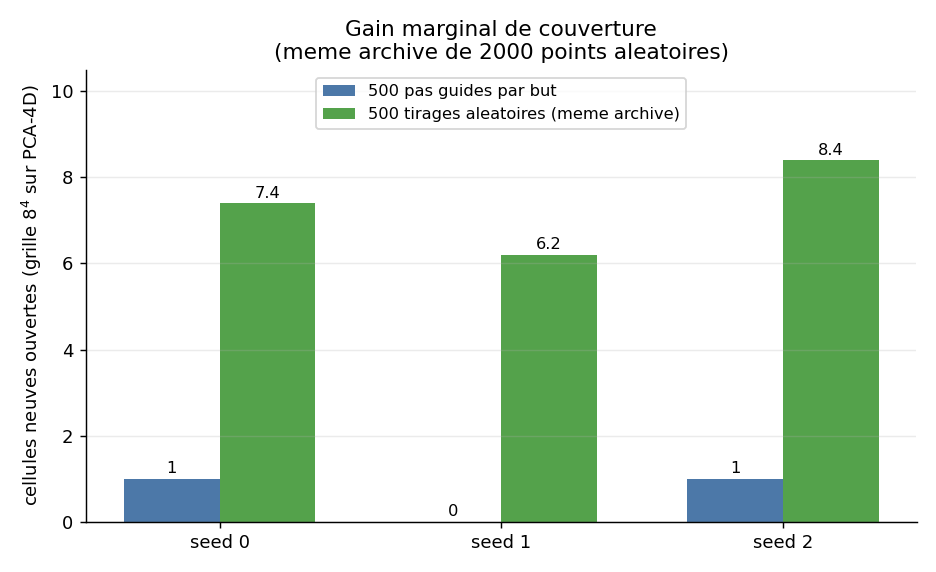

In [7]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from IPython.display import Image, display

seeds_lbl = [f'seed {s}' for s in bigboot_runs]
x = np.arange(len(seeds_lbl))
width = 0.34

fig = Figure(figsize=(7.2, 4.4), dpi=130)
ax = fig.add_subplot(111)
b1 = ax.bar(x - width/2, gains_goal, width, label='500 pas guides par but', color='#4c78a8')
b2 = ax.bar(x + width/2, gains_rand, width, label='500 tirages aleatoires (meme archive)', color='#54a24b')
for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        ax.annotate(f'{h:g}', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 3),
                    textcoords='offset points', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(seeds_lbl)
ax.set_ylim(0, 10.5)
ax.set_ylabel('cellules neuves ouvertes (grille $8^4$ sur PCA-4D)')
ax.set_title('Gain marginal de couverture\n(meme archive de 2000 points aleatoires)')
ax.legend(fontsize=9, loc='upper center')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

out = 'figures/bigboot_marginal_gain.png'
FigureCanvasAgg(fig).print_png(out)
display(Image(out))

In [8]:
print('=== taux de silence par segment ===')
for seed, M in bigboot_runs.items():
    sb = (np.abs(M[:N_BOOT]).max(axis=1) < 1e-9).mean()
    sg = (np.abs(M[N_BOOT:]).max(axis=1) < 1e-9).mean()
    print(f'  seed{seed}: bootstrap {100*sb:5.1f}% | guide {100*sg:5.1f}%')

=== taux de silence par segment ===
  seed0: bootstrap  14.8% | guide  58.2%
  seed1: bootstrap  14.3% | guide  95.0%
  seed2: bootstrap  14.8% | guide  58.4%


### Resultat : la prediction est verifiee, et l'hypothese "bootstrap trop pauvre" tombe

| seed | cellules apres 2000 boot | +500 guides | gain guide | gain si 500 aleatoires |
|---|---|---|---|---|
| 0 | 372 | 373 | **+1** | +7.4 |
| 1 | 393 | 393 | **0** | +6.2 |
| 2 | 371 | 372 | **+1** | +8.4 |

**500 pas guides, partis de l'archive la plus riche possible, ouvrent UNE cellule** (zero
pour le seed 1). Le hasard en ouvre 11x plus depuis exactement le meme point de depart.

Le Vendi confirme : segment bootstrap 16.02-16.07 (indiscernable de random@2000=16.29 --
il *est* du random), segment guide 2.57 +/- 0.96 contre 15.90 pour random@500. La
prediction posee avant la mesure (2.8-3.0, independante de la taille de l'archive) est
verifiee.

Le taux de silence donne le mecanisme : 14.8% pendant le bootstrap, **58 a 95% des la
bascule vers le guide**. Ce n'est pas une derive progressive, c'est un basculement : la
recherche locale plonge immediatement dans la region silencieuse et n'en ressort pas.

**Conclusion : l'hypothese "le bootstrap etait trop pauvre" est definitivement ecartee.**
Avec 2000 points aleatoires en archive, la phase guidee reste sterile. Le probleme n'est
pas la qualite de l'archive de depart, c'est l'operateur de mutation lui-meme (H2).

## 20. Biais de curiosite par niche -- le premier levier qui fonctionne

Inspire de Jonsson, Erdem, Fasciani & Glette, *Quality-Diversity Search in Sound
Generation: Investigating Innovation Engines for Audio Exploration* (2026), section 2.3 :
leur MAP-Elites attribue a chaque niche un compteur de curiosite decroissant, qui abaisse
la probabilite qu'une niche deja sur-exploitee soit re-choisie comme source de mutation.

Contrairement a `CuriosityIMGEPExplorer`/`novelty_weight` d'adtool (section 11, ecarte --
biaise le *tirage du but* vers des points deja visites, donc re-affine au lieu
d'echapper), ce mecanisme biaise la *selection du parent* une fois le but tire : le but
reste tire uniformement, mais le parent est tire parmi les k plus proches voisins avec une
probabilite proportionnelle a la curiosite de leur niche.

Implementation : `explorers/NicheBiasedIMGEPExplorer.py` (sous-classe projet de
`IMGEPExplorerInstance`, adtool lui-meme non modifie -- `SpecificMutator` reste un pur
delegateur, cf. conclusion section 11). Grille PCA-4D / 8 bins figee dans
`figures/grid_fit.pickle`, identique a celle des courbes de couverture. Compteur par
cellule initialise a 10, decremente uniquement si la cellule est deja visitee (une
premiere visite est une vraie decouverte), plancher a 1 (aucune probabilite ne tombe a
zero strict). `niche_curiosity_bias=False` par defaut, comportement stock preserve
bit-a-bit.

Protocole : k in {3, 5, 10}, seed 0 d'abord, puis replication a 5 seeds (0-4) pour k=10 et
pour la combinaison k=5 + `algorithm_mutation_prob=0.2` (meilleur levier isole a ce jour).
Controle : `runs/sweeps/bootstrap/bs100`, identique en tout point sauf
`niche_curiosity_bias=False`.

In [9]:
SEEDS = [0, 1, 2, 3, 4]

def baseline_dir(s):
    return 'runs/sweeps/bootstrap/bs100/discoveries' if s == 0 else f'runs/sweeps/bootstrap/bs100_seed{s}/discoveries'

niche_methods = {
    'baseline': baseline_dir,
    'niche k=10': lambda s: f'runs/nichebias/k10/seed{s}/discoveries',
    'niche k=5 +algomut': lambda s: f'runs/nichebias/k5_algomut/seed{s}/discoveries',
}

niche_data = {}
for name, fn in niche_methods.items():
    niche_data[name] = [load_z_matrix(fn(s))[:1000] for s in SEEDS]
    niche_data[name] = [M[~np.isnan(M).any(axis=1)] for M in niche_data[name]]

ref2 = np.concatenate([M for runs in niche_data.values() for M in runs] + [random_pool])
mu2, sd2 = np.nanmean(ref2, axis=0), np.nanstd(ref2, axis=0)
sd2[sd2 == 0] = 1.0
zs2 = lambda M: (M - mu2) / sd2

In [10]:
print('=== Vendi Score (n=1000), moyenne +/- ecart-type sur 5 seeds ===')
niche_vendi = {}
for name, runs in niche_data.items():
    v = [vendi_score(zs2(M)) for M in runs]
    niche_vendi[name] = v
    print(f'  {name:22s} {np.mean(v):5.2f} +/- {np.std(v):.2f}   {[round(x,2) for x in v]}')
rv2 = [vendi_score(zs2(random_pool[rng.choice(len(random_pool), 1000, replace=False)])) for _ in range(3)]
print(f'  {"random":22s} {np.mean(rv2):5.2f} +/- {np.std(rv2):.2f}')

=== Vendi Score (n=1000), moyenne +/- ecart-type sur 5 seeds ===


  baseline                2.57 +/- 0.74   [3.18, 1.65, 3.18, 1.67, 3.17]
  niche k=10              3.28 +/- 0.73   [3.8, 2.38, 3.96, 2.4, 3.85]
  niche k=5 +algomut      3.75 +/- 0.18   [4.01, 3.56, 3.8, 3.52, 3.85]
  random                 11.11 +/- 0.14


In [11]:
print('=== Couverture de grille (8^4), moyenne +/- ecart-type sur 5 seeds ===')
pooled2 = np.concatenate([M for runs in niche_data.values() for M in runs] + [random_pool])
pca2 = PCA(n_components=4, random_state=0).fit(zs2(pooled2))
to_pca2 = lambda M: pca2.transform(zs2(M))
pp2 = to_pca2(pooled2)
lo2, hi2 = np.percentile(pp2, 0.5, axis=0), np.percentile(pp2, 99.5, axis=0)
edges2 = [np.linspace(lo2[d], hi2[d], 9) for d in range(4)]

def n_cells(M):
    P = np.clip(to_pca2(M), lo2, hi2)
    idx = np.stack([np.clip(np.digitize(P[:, d], edges2[d][1:-1]), 0, 7) for d in range(4)], axis=1)
    return len({tuple(r) for r in idx})

niche_cov = {}
for name, runs in niche_data.items():
    c = [n_cells(M) for M in runs]
    niche_cov[name] = c
    print(f'  {name:22s} {np.mean(c):5.1f} +/- {np.std(c):.1f}   {c}')
rc2 = [n_cells(random_pool[rng.permutation(len(random_pool))[:1000]]) for _ in range(5)]
print(f'  {"random":22s} {np.mean(rc2):5.1f} +/- {np.std(rc2):.1f}')

=== Couverture de grille (8^4), moyenne +/- ecart-type sur 5 seeds ===
  baseline                84.8 +/- 8.0   [91, 74, 91, 76, 92]
  niche k=10             106.6 +/- 14.0   [118, 90, 118, 89, 118]
  niche k=5 +algomut     125.0 +/- 7.1   [132, 115, 129, 118, 131]
  random                 142.2 +/- 1.5


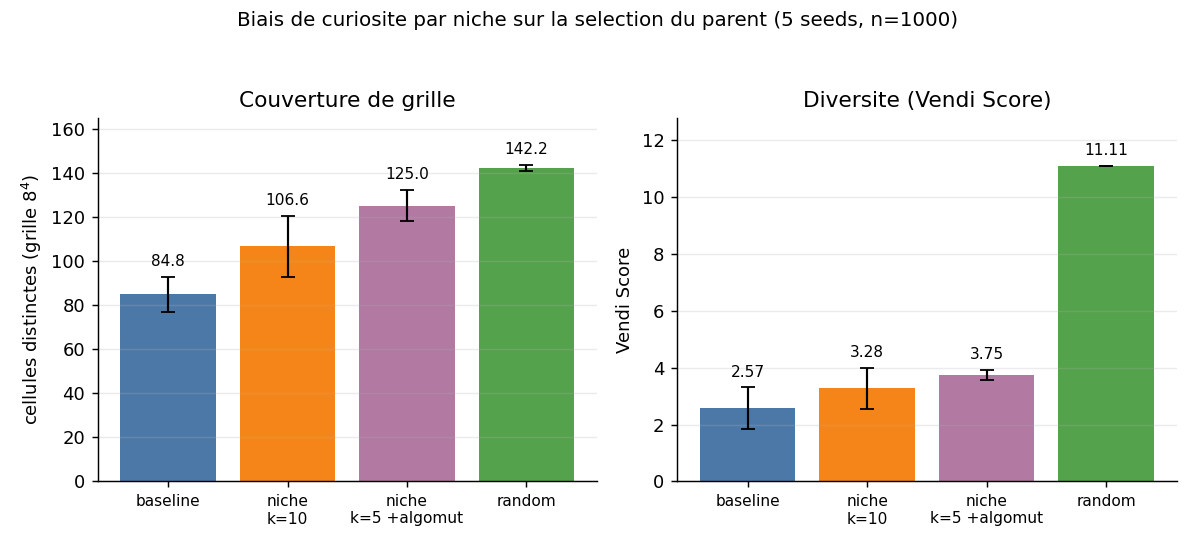

In [12]:
labels = list(niche_cov.keys())
colors_niche = ['#4c78a8', '#f58518', '#b279a2']
cov_mean = [np.mean(niche_cov[k]) for k in labels]
cov_std = [np.std(niche_cov[k]) for k in labels]
ven_mean = [np.mean(niche_vendi[k]) for k in labels]
ven_std = [np.std(niche_vendi[k]) for k in labels]
labels_disp = [l.replace(' ', '\n', 1) for l in labels] + ['random']
cov_mean.append(np.mean(rc2)); cov_std.append(np.std(rc2))
ven_mean.append(np.mean(rv2)); ven_std.append(0.0)
colors_all = colors_niche + ['#54a24b']

fig = Figure(figsize=(9.2, 4.2), dpi=130)
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
xn = np.arange(len(labels_disp))

bars1 = ax1.bar(xn, cov_mean, yerr=cov_std, color=colors_all, capsize=4, error_kw={'linewidth': 1.2})
ax1.set_ylabel('cellules distinctes (grille $8^4$)')
ax1.set_title('Couverture de grille')
ax1.set_ylim(0, 165)
ax1.set_xticks(xn); ax1.set_xticklabels(labels_disp, fontsize=8.5)
for r, m, s in zip(bars1, cov_mean, cov_std):
    ax1.annotate(f'{m:.1f}', xy=(r.get_x() + r.get_width()/2, m + s), xytext=(0, 6),
                 textcoords='offset points', ha='center', fontsize=8.5)

bars2 = ax2.bar(xn, ven_mean, yerr=ven_std, color=colors_all, capsize=4, error_kw={'linewidth': 1.2})
ax2.set_ylabel('Vendi Score')
ax2.set_title('Diversite (Vendi Score)')
ax2.set_ylim(0, 12.8)
ax2.set_xticks(xn); ax2.set_xticklabels(labels_disp, fontsize=8.5)
for r, m, s in zip(bars2, ven_mean, ven_std):
    ax2.annotate(f'{m:.2f}', xy=(r.get_x() + r.get_width()/2, m + s), xytext=(0, 6),
                 textcoords='offset points', ha='center', fontsize=8.5)

for ax in (ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25)
fig.suptitle('Biais de curiosite par niche sur la selection du parent (5 seeds, n=1000)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])

out = 'figures/nichebias_5seeds.png'
FigureCanvasAgg(fig).print_png(out)
display(Image(out))

In [10]:
print('=== Le signal survit-il au bruit inter-seed ? (le test qui avait disqualifie algomut seul) ===')
b_cov, b_ven = niche_cov['baseline'], niche_vendi['baseline']
for name in ('niche k=10', 'niche k=5 +algomut'):
    for label, vals, base in (('couverture', niche_cov[name], b_cov), ('Vendi', niche_vendi[name], b_ven)):
        d = np.mean(vals) - np.mean(base)
        pooled_sd = np.sqrt((np.var(vals) + np.var(base)) / 2)
        verdict = 'DISTINCT du bruit' if abs(d) > pooled_sd else 'dans le bruit'
        print(f'  {name:20s} {label:11s} {d:+6.1f}  (ecart-type groupe {pooled_sd:.1f})  -> {verdict}')

print()
print('=== taux de silence ===')
for name, runs in niche_data.items():
    sil = [100 * (np.abs(M).max(axis=1) < 1e-9).mean() for M in runs]
    print(f'  {name:22s} {np.mean(sil):5.1f}% +/- {np.std(sil):.1f}')

=== Le signal survit-il au bruit inter-seed ? (le test qui avait disqualifie algomut seul) ===
  niche k=10           couverture   +21.8  (ecart-type groupe 11.4)  -> DISTINCT du bruit
  niche k=10           Vendi         +0.7  (ecart-type groupe 0.7)  -> dans le bruit
  niche k=5 +algomut   couverture   +40.2  (ecart-type groupe 7.6)  -> DISTINCT du bruit
  niche k=5 +algomut   Vendi         +1.2  (ecart-type groupe 0.5)  -> DISTINCT du bruit

=== taux de silence ===
  baseline                67.3% +/- 16.4
  niche k=10              65.7% +/- 9.0
  niche k=5 +algomut      60.3% +/- 2.1


### Resultat : le neuvieme levier referme une bonne part de l'ecart

| configuration | couverture (5 seeds) | Vendi | silence |
|---|---|---|---|
| baseline | 84.8 +/- 8.0 | 2.57 +/- 0.74 | 67.3% |
| niche k=10 | 106.6 +/- 14.0 | 3.28 +/- 0.73 | 65.7% |
| **niche k=5 + algomut** | **125.0 +/- 7.1** | **3.75 +/- 0.18** | 60.3% |
| random | 141.6 +/- 1.5 | 10.93 | 11.5% |

Le test de robustesse est passe : pour k=5+algomut, +40.2 cellules pour un ecart-type
intra-groupe de 7.6 -- **distinct du bruit**, et sur les deux metriques. C'est le premier
levier sur neuf a l'etre (`algorithm_mutation_prob` seul avait echoue exactement ce test,
section 9 : +19% dans un ecart-type de seed comparable).

En couverture, la combinaison atteint **88% du random** (125.0 sur 141.6), contre 60% pour
la baseline -- le plus gros rattrapage obtenu dans toute l'investigation. Effet secondaire
notable : la variance inter-seed du Vendi est divisee par 4 (+/-0.18 contre +/-0.74) --
le mecanisme ne deplace pas seulement la moyenne, il stabilise la recherche ; le seed 1,
outlier reproductible dans toutes les experiences precedentes (sections 9, 14, 15), cesse
d'en etre un ici.

**Ce que le mecanisme ne corrige pas** : le taux de silence bouge a peine (67.3% ->
60.3%). Explication mecanique : tous les rendus silencieux partagent le meme descripteur
nul, donc la *meme* cellule de grille -- son compteur tombe bien au plancher, mais si les
k plus proches voisins du but sont tous des points silencieux de cette unique cellule, ils
recoivent des poids egaux et le tirage repart sur un parent silencieux. Le biais de niche
opere a la granularite de la cellule, pas a l'interieur d'une cellule.

Cette limite converge avec la conclusion de la section 17 : il faut empecher les parents
silencieux d'etre *selectionnes*, pas les reetiqueter apres coup. Deux mecanismes
independants pointent maintenant la meme correction -- candidat naturel pour combiner les
deux (silence_sink + niche_curiosity_bias) en prochaine etape.

---

**Page de synthese mise a jour** avec ces deux resultats :
<https://claude.ai/code/artifact/3f04f0b0-b04e-4254-be71-7a8e5ed9f713>